# **Table of contents**

[**Exploratory Data Analysis (EDA)**](#exploratory-data-analysis-eda)

- [**1. Importing Libraries**](#1-importing-libraries)
- [**2. Problem statement and data collection**](#2-problem-statement-and-data-collection)
- [**3. Exploration and data cleaning**](#3-exploration-and-data-cleaning)
  - [**3.1 Eliminate duplicates**](#31-eliminate-duplicates)
  - [**3.2 Eliminate irrelevant information**](#32-eliminate-irrelevant-information)
- [**4. Analysis of univariate variables**](#4-analysis-of-univariate-variables)
  - [**4.1 Numerical Variables - Analysis and Conclusions**](#41-numerical-variables---analysis-and-conclusions)
  - [**4.2 Categorical Variables - Analysis and Conclusions**](#42-Categorical-Variables---Analysis-and-Conclusions)
- [**5. Multivariate Analysis**](#5-Multivariate-Analysis)
    - [**5.1 Numerical vs Numerical Analysis**](#51-Numerical-vs-Numerical-Analysis)
    - [**5.2 Categorical vs Categorical Analysis**](#52-Categorical-vs-Categorical-Analysis)
    - [**5.3 Encoding Categorical Values and Saving JSON files**](#53-Encoding-Categorical-Values-and-Saving-JSON-files)
    - [**5.4 Correlation analysis**](#54-Correlation-analysis)
- [**6. Analysing all the Data at Once**](#6.-Analysing-all-the-Data-at-Once)
- [**7. Feature Engineering**](#7.-Feature-Engineering)
    - [**7.1 Outliers analysis**](#71-Outliers-analysis)
    - [**7.2 Remove outliers**](#72-Remove-outliers)
    - [**7.3 Split Train & Test**](#73-Split-Train-&-Test)
    - [**7.4 Data Normalization**](#74-Data-Normalization)
    - [**7.5 Min Max Scaler Data**](#75-Min-Max-Scaler-Data)




[**MACHINE LEARNING**](#Machine-Learning)

- [**1. LINEAR REGRESSION**](#1.-LINEAR-REGRESSION)
- [**2. RANDOM FOREST**](#2.-RANDOM-FOREST)
- [**3. XGBOOST** ](#3.-XGBOOST)
- [**4. K MEANS** ](#4.-K-MEANS)
- [**5. KNN**](#5-KNN)
- - [**6. Model Evaluation with Random Forest and XGBoost (with Hyperparameter Tuning)**](#6-model-evaluation-with-random-forest-and-xgboost-with-hyperparameter-tuning)
    - [**6.1 Saving the XGBoost (mix) Model**](#61-Saving-the-XGBoost-(mix)-Model)
- [**7. STREAMLIT: vid. app.py file**](#streamlit-vid-apppy-file)

-------------------------------------------------------------------------------

## **Exploratory Data Analysis (EDA)**

### **1. Importing Libraries**

In [ ]:
import json
import logging
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import streamlit as st

from sklearn.model_selection import train_test_split, RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold


### **2. Problem statement and data collection**

In [2]:
esg_csv = "../data/raw/sp500_esg_ceo_info-filtered.csv"  
esg_df = pd.read_csv(esg_csv)

logging.getLogger("yfinance").setLevel(logging.ERROR)

print("Columns CSV ESG:", esg_df.columns)
print("Number of tickers in CSV:", esg_df["Ticker"].nunique())

Columns CSV ESG: Index(['Ticker', 'ESG Score', 'Governance Score', 'Environment Score',
       'Social Score', 'ESG Score Date', 'ESG Status', 'CEO Full Name',
       'CEO Gender', 'CEO Status', 'Year'],
      dtype='object')
Number of tickers in CSV: 426


This block loads and inspects the ESG dataset containing S&P 500 companies with CEO and ESG information, and prepares for financial data retrieval.  

Key steps and purpose:  

1. **Data loading:**  
   - The CSV file `sp500_esg_ceo_info-filtered.csv` is read into a DataFrame `esg_df`.  
   - This dataset contains ESG scores, governance metrics, and CEO-related information for each ticker.  

2. **Suppressing unnecessary logs:**  
   - `yfinance` logging is set to `ERROR` to avoid verbose output when retrieving or processing financial data later.  

3. **About yfinance:**  
   - `yfinance` is a Python library used to download historical market data from Yahoo Finance, including stock prices, volumes, dividends, and other financial metrics.  
   - In this project, `yfinance` will be used to merge **financial performance data** with ESG and CEO information, enabling combined analysis of market and sustainability features.  

4. **Initial inspection:**  
   - Columns are printed to verify which features are present.  
   - The number of unique tickers is displayed to ensure the dataset covers the expected number of companies.  

**Conclusion:**  
This step is essential for **data exploration and validation**, confirming that the ESG dataset is correctly loaded and structured, and preparing for financial data integration via `yfinance`.

In [ ]:
tickers = esg_df["Ticker"].dropna().unique().tolist()[:400]

start_date = "2022-01-01"
end_date = "2023-12-31"

all_data = []

This block prepares the list of tickers and initializes parameters for retrieving historical financial data.  

Key steps and purpose:  

1. **Selecting tickers:**  
   - Unique tickers are extracted from the ESG dataset (`esg_df["Ticker"]`).  
   - Any missing values are removed with `dropna()`.  
   - Only the first 400 tickers are selected for processing, likely to limit computation time or API requests.  

2. **Setting the date range:**  
   - `start_date` and `end_date` define the historical window for financial data retrieval: from January 1, 2022, to December 31, 2023.  

3. **Initializing storage:**  
   - `all_data` is an empty list that will later store the downloaded financial data for each ticker, facilitating subsequent merging with ESG information and analysis.  

**Conclusion:**  
This step sets up the **tickers, timeframe, and storage structure** required to efficiently download and manage historical financial market data for integration with ESG features.

In [4]:
# Silence yfinance 
logging.getLogger("yfinance").setLevel(logging.CRITICAL)

batch_size = 400
for i in range(0, len(tickers), batch_size):
    batch = tickers[i:i+batch_size]
    print(f"\nDonwload batch {i//batch_size + 1} of {len(tickers)//batch_size + 1}...")
    
    try:
        df = yf.download(
            batch,
            start=start_date,
            end=end_date,
            progress=False,
            auto_adjust=False,  
            threads=False 
        )
        
        # Converting from multi-index columns to simple columns
        df = df.stack(level=1, future_stack=True).reset_index()
        df.rename(columns={"level_1": "Ticker"}, inplace=True)
        
        all_data.append(df)
    except Exception as e:
        print(f"Error in batch {i//batch_size + 1}: {e}")


Donwload batch 1 of 2...


This block downloads historical financial data from Yahoo Finance (`yfinance`) in batches to manage API requests efficiently.  

Key steps and purpose:  

1. **Batch processing:**  
   - Tickes are processed in batches of 400 to avoid overloading the API or hitting request limits.  
   - The loop iterates through all tickers, downloading data for each batch.  

2. **Data download:**  
   - `yf.download` retrieves historical stock data for each batch between `start_date` and `end_date`.  
   - `progress=False` disables progress bars for cleaner output.  
   - `auto_adjust=False` ensures raw prices are kept for further processing.  

3. **Data transformation:**  
   - The multi-index columns returned by `yfinance` are stacked and reset to a flat structure.  
   - The second level of the index is renamed as `"Ticker"` to clearly identify the stock associated with each row.  
   - Each batch is appended to the `all_data` list for later concatenation.  

4. **Error handling:**  
   - Any exceptions during a batch download are caught and printed.  
   - In this case, 8 tickers failed to download, but the process successfully retrieved data for **392 tickers**.  

**Conclusion:**  
This approach ensures robust and efficient downloading of historical stock data, even in the presence of a few failed tickers, while preparing a clean, flat DataFrame ready for merging with ESG information.

In [5]:
# Combine all financial data
fin_df = pd.concat(all_data, ignore_index=True)

print(f"\nFinancial data: {fin_df.shape}")


Financial data: (200400, 8)


This block combines all the downloaded financial batches into a single consolidated DataFrame.  

Key steps and purpose:  

1. **Concatenation:**  
   - `pd.concat` merges all DataFrames stored in `all_data` into one unified `fin_df`.  
   - `ignore_index=True` resets the row indices to ensure a continuous, clean index across all batches.  

2. **Inspection:**  
   - The shape of the resulting DataFrame (`fin_df.shape`) is printed to verify the number of rows and columns, confirming that the financial data has been successfully aggregated.  

**Conclusion:**  
After this step, `fin_df` contains all historical stock data for the retrieved tickers, ready to be merged with ESG features or used for further analysis and modeling.


In [6]:
# Merge with ESG data (by ticker)
dataset_final = pd.merge(fin_df, esg_df, on="Ticker", how="inner")

This block merges the financial data with ESG and CEO information to create the final dataset for analysis.  

Key steps and purpose:  

1. **Merging datasets:**  
   - `fin_df` (historical financial data) is merged with `esg_df` (ESG and CEO information) using the `"Ticker"` column as the key.  
   - `how="inner"` ensures that only tickers present in both datasets are included, removing any unmatched entries.  

2. **Purpose of the merge:**  
   - Combining financial and ESG features allows the creation of a **comprehensive dataset** that captures both market performance and sustainability metrics.  
   - This merged dataset (`dataset_final`) serves as the **primary input for feature engineering, modeling, and analysis**.  

**Conclusion:**  
The resulting `dataset_final` integrates financial and ESG information at the ticker level, providing a robust foundation for exploratory analysis and predictive modeling.


In [7]:
# Create volatility features to obtain 2 potential targets (y) for our future predictive model
dataset_final["Daily_Return"] = dataset_final.groupby("Ticker")["Adj Close"].pct_change()
dataset_final["Daily_Volatility"] = (
    dataset_final.groupby("Ticker")["Daily_Return"]
    .rolling(5)
    .std()
    .reset_index(0, drop=True)
)

/tmp/ipykernel_44831/70001656.py:2: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  dataset_final["Daily_Return"] = dataset_final.groupby("Ticker")["Adj Close"].pct_change()


This block creates **volatility-related features** to serve as potential target variables for future predictive modeling.  

Key steps and purpose:  

1. **Daily returns:**  
   - `Daily_Return` is calculated as the percentage change of the adjusted closing price (`Adj Close`) for each ticker.  
   - Grouping by `"Ticker"` ensures that returns are computed independently for each stock.  

2. **Rolling volatility:**  
   - `Daily_Volatility` is calculated as the rolling standard deviation of `Daily_Return` over a 5-day window.  
   - This feature captures short-term price fluctuations, providing insight into market risk and volatility patterns for each ticker.  

3. **Purpose:**  
   - These features can be used as **target variables (y)** for predictive models aiming to forecast daily returns or volatility.  
   - They also serve as **key indicators** in risk analysis and in understanding the relationship between ESG factors and market behavior.  

**Conclusion:**  
By adding `Daily_Return` and `Daily_Volatility`, the dataset now contains both **financial outcomes and derived risk metrics**, enabling comprehensive modeling and analysis.


In [8]:
# Save final CSV
dataset_final.to_csv("dataset_final.csv", index=False)

print(f"\nDataset saved as 'dataset_final.csv'")
print("Final shape:", dataset_final.shape)
print("\nFirst rows:\n", dataset_final.head())

dataset_final.info()


Dataset saved as 'dataset_final.csv'
Final shape: (200400, 20)

First rows:
         Date Ticker   Adj Close       Close        High         Low  \
0 2022-01-03      A  152.625916  156.479996  159.440002  153.929993   
1 2022-01-03    AAL   18.750000   18.750000   19.180000   18.200001   
2 2022-01-03   AAPL  178.443146  182.009995  182.880005  177.710007   
3 2022-01-03   ABBV  117.621178  135.419998  135.699997  133.509995   
4 2022-01-03    ABT  129.569733  139.039993  139.830002  137.210007   

         Open       Volume  ESG Score  Governance Score  Environment Score  \
0  159.000000    1606300.0      15.24              6.26               0.34   
1   18.230000   42781000.0      29.10              5.26              11.53   
2  177.830002  104487900.0      16.68              9.18               0.65   
3  135.410004    6839800.0      27.84              9.95               1.12   
4  139.429993    6688100.0      24.98              8.36               3.03   

   Social Score ESG Score 

This block saves the final, fully processed dataset to a CSV file and provides a brief inspection of its structure.  

Key steps and purpose:  

1. **Saving the dataset:**  
   - `dataset_final.to_csv("dataset_final.csv", index=False)` writes the complete dataset to a CSV file without including the index.  
   - This allows for easy sharing, reproducibility, and future use in modeling or analysis.  

2. **Inspection and verification:**  
   - The shape of the dataset (`dataset_final.shape`) is printed to confirm the number of rows and columns.  
   - The first few rows are displayed to visually check that the data has been merged and processed correctly.  
   - `dataset_final.info()` provides an overview of column types, non-null counts, and memory usage, helping ensure data integrity and readiness for analysis.  

**Conclusion:**  
After this step, `dataset_final.csv` serves as the **final, clean, and comprehensive dataset**, containing financial data, ESG features, and derived volatility metrics, ready for feature engineering, modeling, or reporting.


### **3. Exploration and data cleaning**

In [9]:
dataset_final.head()

,Date,Ticker,Adj Close,Close,High,Low,Open,Volume,ESG Score,Governance Score,Environment Score,Social Score,ESG Score Date,ESG Status,CEO Full Name,CEO Gender,CEO Status,Year,Daily_Return,Daily_Volatility
0,2022-01-03,A,152.625916,156.479996,159.440002,153.929993,159.000000,1606300.0,15.24,6.26,0.34,8.65,01/01/2023,success,Mr. Michael R. McMullen,male,success,23,NaN,NaN
1,2022-01-03,AAL,18.750000,18.750000,19.180000,18.200001,18.230000,42781000.0,29.10,5.26,11.53,12.31,01/01/2023,success,Mr. Robert D. Isom Jr.,male,success,23,NaN,NaN
2,2022-01-03,AAPL,178.443146,182.009995,182.880005,177.710007,177.830002,104487900.0,16.68,9.18,0.65,6.86,01/08/2022,success,Mr. Timothy D. Cook,male,success,22,NaN,NaN
3,2022-01-03,ABBV,117.621178,135.419998,135.699997,133.509995,135.410004,6839800.0,27.84,9.95,1.12,16.77,01/08/2022,success,Mr. Richard A. Gonzalez,male,success,22,NaN,NaN
4,2022-01-03,ABT,129.569733,139.039993,139.830002,137.210007,139.429993,6688100.0,24.98,8.36,3.03,13.59,01/08/2022,success,Mr. Robert B. Ford,male,success,22,NaN,NaN


In [10]:
dataset_final.shape

(200400, 20)

In [11]:
dataset_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200400 entries, 0 to 200399
Data columns (total 20 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Date               200400 non-null  datetime64[ns]
 1   Ticker             200400 non-null  object        
 2   Adj Close          196392 non-null  float64       
 3   Close              196392 non-null  float64       
 4   High               196392 non-null  float64       
 5   Low                196392 non-null  float64       
 6   Open               196392 non-null  float64       
 7   Volume             196392 non-null  float64       
 8   ESG Score          200400 non-null  float64       
 9   Governance Score   200400 non-null  float64       
 10  Environment Score  200400 non-null  float64       
 11  Social Score       200400 non-null  float64       
 12  ESG Score Date     200400 non-null  object        
 13  ESG Status         200400 non-null  object  

#### **3.1 Eliminate duplicates**


In [12]:
dataset_final.drop_duplicates()

,Date,Ticker,Adj Close,Close,High,Low,Open,Volume,ESG Score,Governance Score,Environment Score,Social Score,ESG Score Date,ESG Status,CEO Full Name,CEO Gender,CEO Status,Year,Daily_Return,Daily_Volatility
0,2022-01-03,A,152.625916,156.479996,159.440002,153.929993,159.000000,1606300.0,15.24,6.26,0.34,8.65,01/01/2023,success,Mr. Michael R. McMullen,male,success,23,NaN,NaN
1,2022-01-03,AAL,18.750000,18.750000,19.180000,18.200001,18.230000,42781000.0,29.10,5.26,11.53,12.31,01/01/2023,success,Mr. Robert D. Isom Jr.,male,success,23,NaN,NaN
2,2022-01-03,AAPL,178.443146,182.009995,182.880005,177.710007,177.830002,104487900.0,16.68,9.18,0.65,6.86,01/08/2022,success,Mr. Timothy D. Cook,male,success,22,NaN,NaN
3,2022-01-03,ABBV,117.621178,135.419998,135.699997,133.509995,135.410004,6839800.0,27.84,9.95,1.12,16.77,01/08/2022,success,Mr. Richard A. Gonzalez,male,success,22,NaN,NaN
4,2022-01-03,ABT,129.569733,139.039993,139.830002,137.210007,139.429993,6688100.0,24.98,8.36,3.03,13.59,01/08/2022,success,Mr. Robert B. Ford,male,success,22,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200395,2023-12-29,VRSN,204.808975,205.960007,207.119995,204.500000,206.660004,450200.0,21.44,5.93,4.74,10.77,01/01/2023,success,Mr. D. James Bidzos,male,success,23,-0.001551,0.005456
200396,2023-12-29,VTR,47.474957,49.840000,50.430000,49.830002,50.099998,1748300.0,12.75,5.73,2.75,4.28,01/01/2023,success,Ms. Debra A. Cafaro,female,success,23,-0.013069,0.009848
200397,2023-12-29,WRB,45.528275,47.146667,47.240002,46.740002,47.026669,1179000.0,21.97,12.04,1.97,7.95,01/01/2023,success,Mr. William Robert Berkley Jr.,male,success,23,0.004260,0.003641
200398,2023-12-29,XOM,94.074997,99.980003,100.589996,99.620003,100.370003,17746400.0,36.47,8.10,18.55,9.82,01/08/2022,success,Mr. Darren W. Woods,male,success,22,-0.002096,0.006790


This removes duplicate rows from the dataset to ensure data integrity and prevent biased results in analysis or modeling.

In [13]:
dataset_final.dropna(inplace=True)

This removes any rows with missing values to ensure the dataset is complete and ready for analysis or modeling.

In [14]:
dataset_final.shape

(194432, 20)

The final dataset contains 194,432 rows and 20 columns, confirming the data size after cleaning and preprocessing.

#### **3.2 Eliminate irrelevant information**

In [15]:
tickers_only = dataset_final[['Ticker']].drop_duplicates()  

tickers_only.to_csv("tickers_only.csv", index=False)

This extracts the unique tickers from the final dataset and saves them to `tickers_only.csv` for reference or future use.

In [16]:
dataset_final.drop(["CEO Full Name", "CEO Status"], axis = 1, inplace = True)
dataset_final.head()

,Date,Ticker,Adj Close,Close,High,Low,Open,Volume,ESG Score,Governance Score,Environment Score,Social Score,ESG Score Date,ESG Status,CEO Gender,Year,Daily_Return,Daily_Volatility
2000,2022-01-10,A,141.584732,145.160004,145.309998,140.860001,143.289993,2548100.0,15.24,6.26,0.34,8.65,01/01/2023,success,male,23,0.000069,0.016297
2001,2022-01-10,AAL,18.790001,18.790001,19.389999,18.680000,19.240000,25707700.0,29.10,5.26,11.53,12.31,01/01/2023,success,male,23,-0.025415,0.025821
2002,2022-01-10,AAPL,168.815567,172.190002,172.500000,168.169998,169.080002,106765600.0,16.68,9.18,0.65,6.86,01/08/2022,success,male,22,0.000116,0.011682
2003,2022-01-10,ABBV,118.463669,136.389999,136.899994,134.570007,135.080002,9794400.0,27.84,9.95,1.12,16.77,01/08/2022,success,male,22,0.011195,0.006615
2004,2022-01-10,ABT,126.047203,135.259995,135.500000,133.919998,134.789993,5975600.0,24.98,8.36,3.03,13.59,01/08/2022,success,male,22,-0.002213,0.010479


These columns (`CEO Full Name` and `CEO Status`) are dropped because they are **not relevant for our analysis**.  
Including them would not provide predictive value and could introduce unnecessary noise, so removing them helps keep the dataset focused on **financial and ESG features**.

In [17]:
dataset_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 194432 entries, 2000 to 200399
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Date               194432 non-null  datetime64[ns]
 1   Ticker             194432 non-null  object        
 2   Adj Close          194432 non-null  float64       
 3   Close              194432 non-null  float64       
 4   High               194432 non-null  float64       
 5   Low                194432 non-null  float64       
 6   Open               194432 non-null  float64       
 7   Volume             194432 non-null  float64       
 8   ESG Score          194432 non-null  float64       
 9   Governance Score   194432 non-null  float64       
 10  Environment Score  194432 non-null  float64       
 11  Social Score       194432 non-null  float64       
 12  ESG Score Date     194432 non-null  object        
 13  ESG Status         194432 non-null  object    

## **4. Analysis of univariate variables**

### **4.1 Numerical Variables - Analysis and Conclusions**


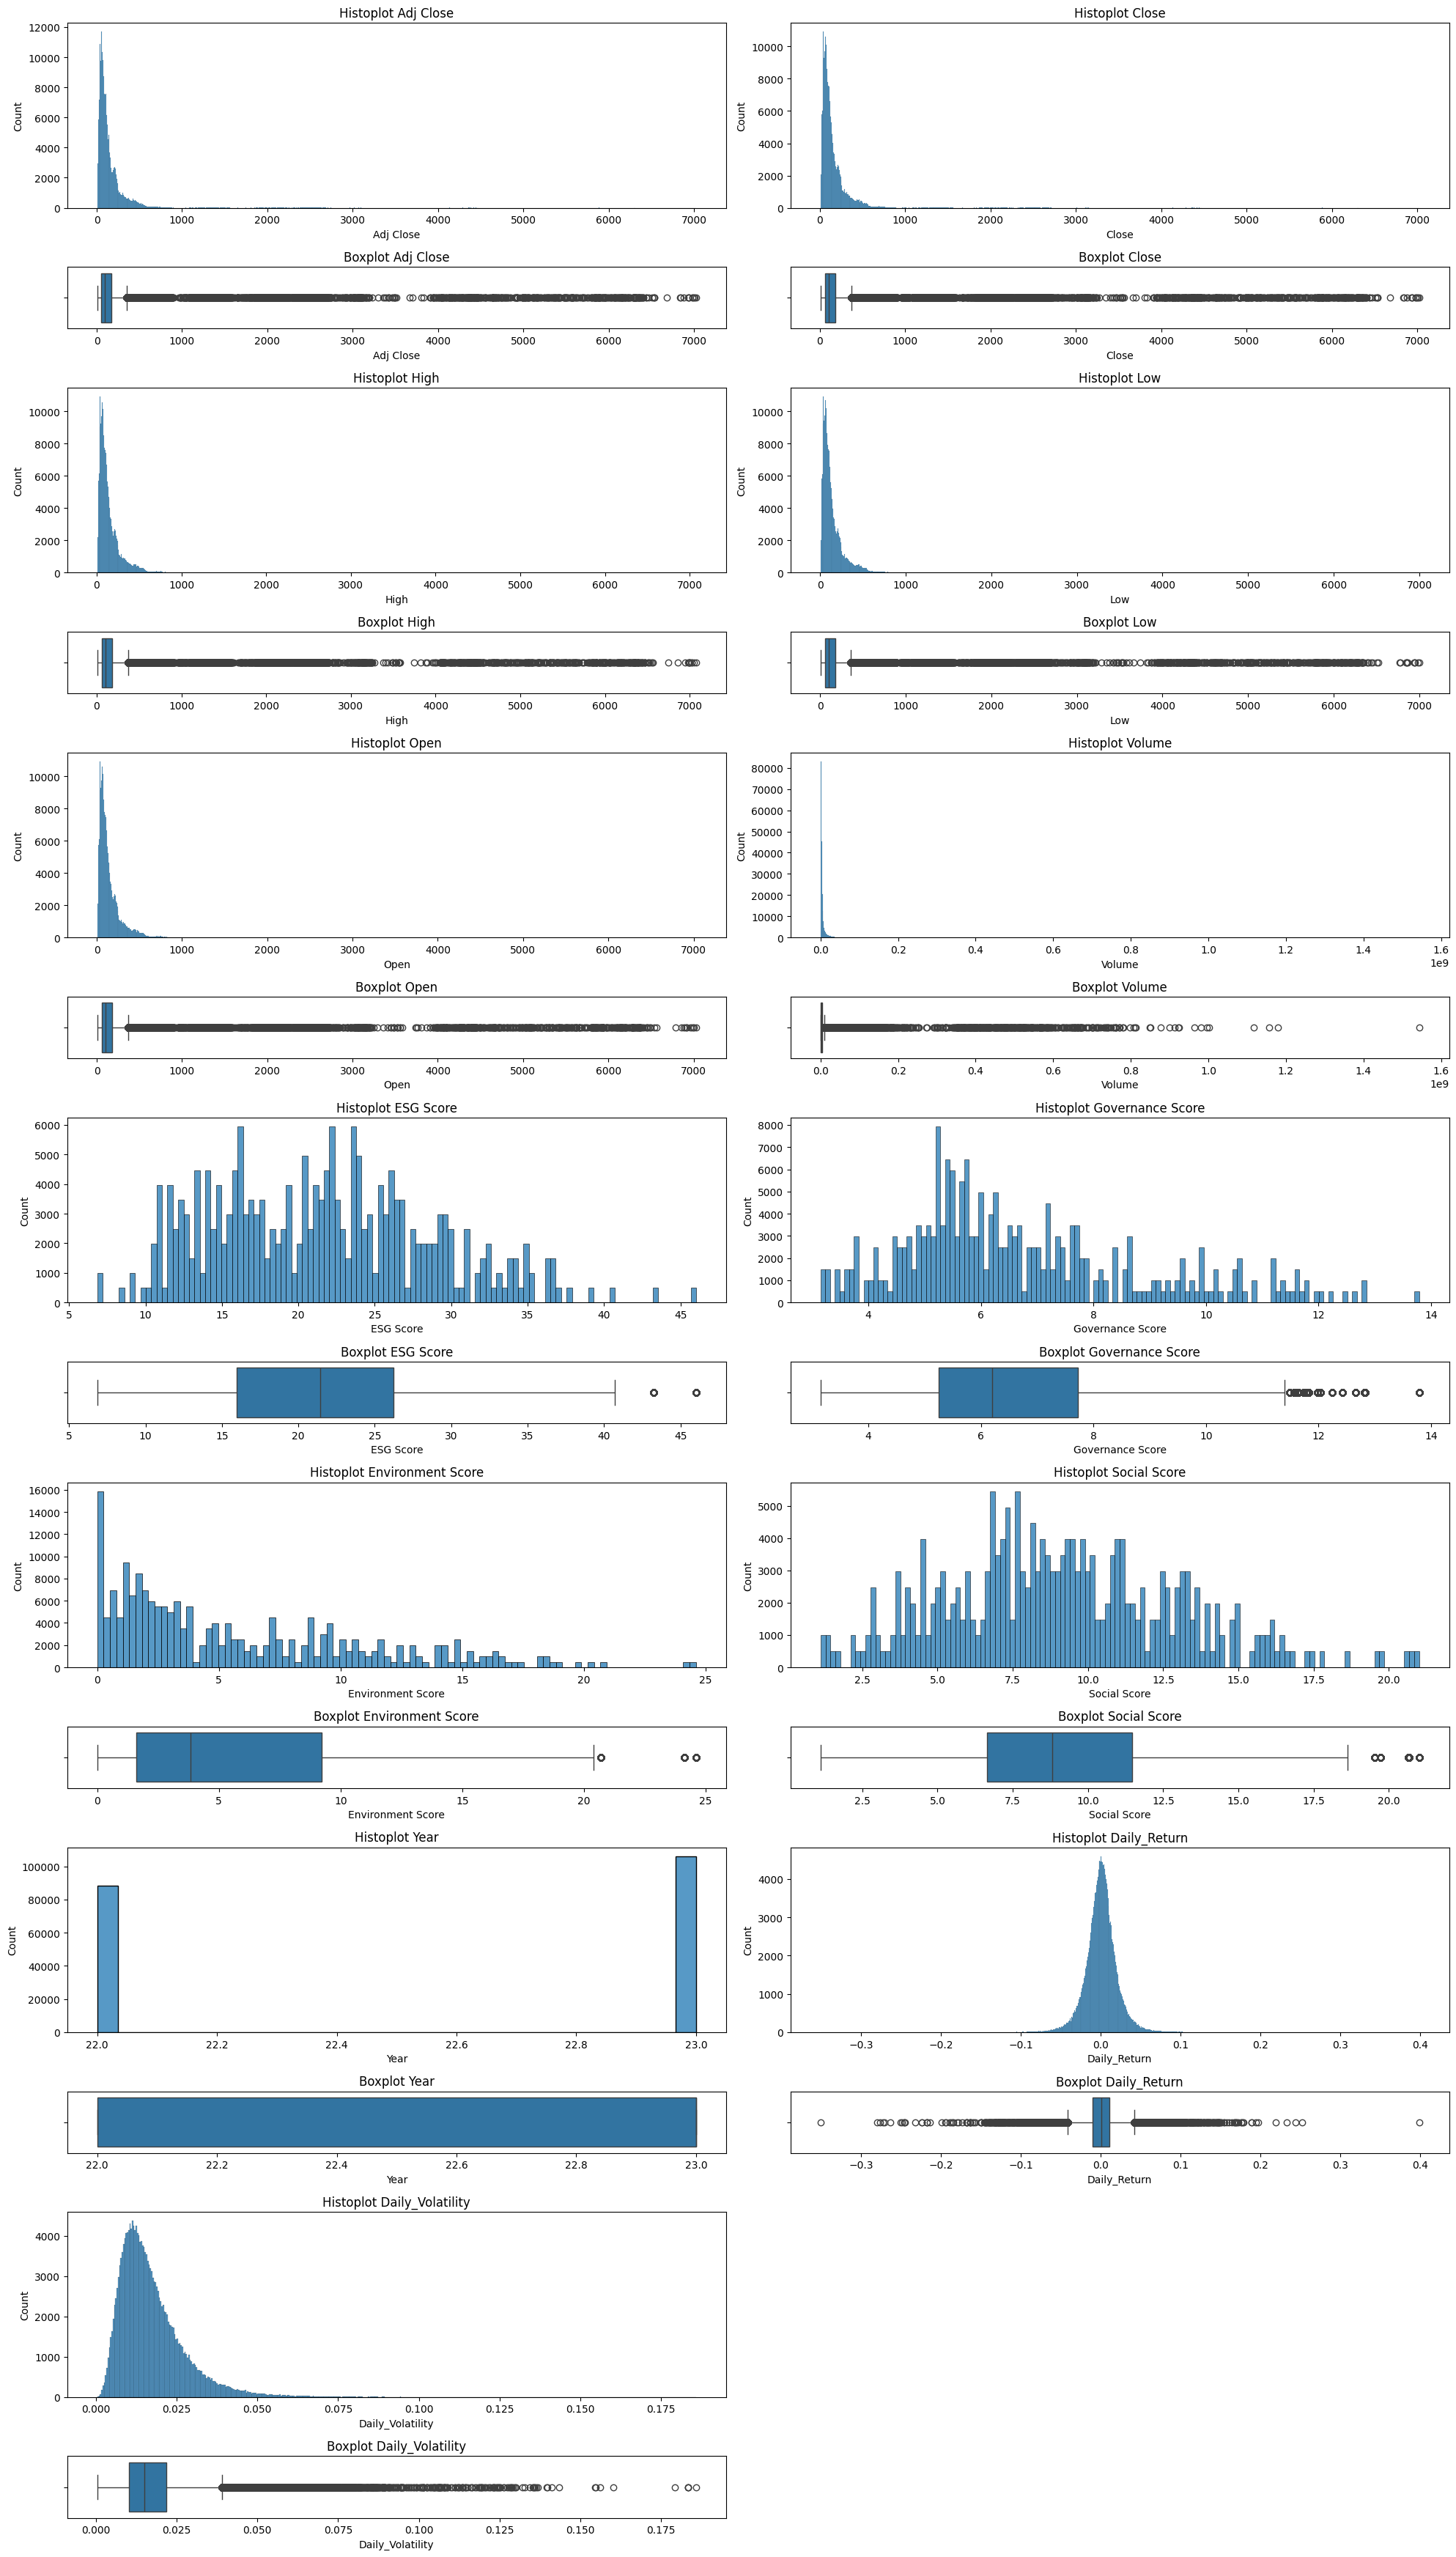

In [14]:
numerical_variables = dataset_final.select_dtypes(include='number').columns
num_vars = len(numerical_variables)

ncols = 2
nrows = num_vars // ncols + (num_vars % ncols)
total_rows = nrows * 2  

fig, axes = plt.subplots(
    nrows=total_rows,
    ncols=ncols,
    figsize=(20, total_rows * 2.5),
    gridspec_kw={"height_ratios": [6, 2] * nrows}
)

axes = axes.reshape(total_rows, ncols)

# Automatic plot
for i, var in enumerate(numerical_variables):
    row = (i // ncols) * 2
    col = i % ncols

    # Histoplot
    sns.histplot(data=dataset_final, x=var, ax=axes[row, col])
    axes[row, col].set_title(f"Histoplot {var}")

    # Boxplot
    sns.boxplot(data=dataset_final, x=var, ax=axes[row + 1, col])
    axes[row + 1, col].set_title(f"Boxplot {var}")

# Turn off unused axes
for j in range(i + 1, nrows * ncols):
    row = (j // ncols) * 2
    col = j % ncols
    axes[row, col].axis("off")
    axes[row + 1, col].axis("off")

plt.tight_layout()
plt.show()

**Conclusions**:

- **Adj Close, Close, High, Low, Open (Price Features)**: Distributions are heavily right-skewed with most values clustered at the lower end and many extreme outliers stretching to very high prices. 

- **Volume**: Extremely right-skewed with a majority of low-volume observations and very large outliers in trading activity.

- **ESG Score**: Distribution is spread across discrete values with peaks around 20–25. The spread is relatively uniform, with few significant outliers.

- **Governance Score**: Fairly symmetrical distribution, centered around 5–8, with no extreme outliers.

- **Environment Score**: Right-skewed distribution, concentrated at low values (0–5), with some outliers at higher scores.

- **Social Score**: Values are more evenly spread, with some clustering at lower scores and a few mild outliers.

- **Year**: The dataset only spans a very short time window, specifically between 2022 and 2023. No outliers are present, confirming that all observations fall neatly within this two-year range.

- **Daily Return**: Distribution is centered around 0, approximately symmetric but with heavy tails and many extreme values (both positive and negative).

- **Daily Volatility**: Right-skewed, with most values between 0–0.05 and a long tail of outliers showing high volatility periods.

### **4.2 Categorical Variables - Analysis and Conclusions**

In [19]:
# CATEGORICALS

categorical_variables = dataset_final.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical Variables:", categorical_variables)

Categorical Variables: ['Ticker', 'ESG Score Date', 'ESG Status', 'CEO Gender']


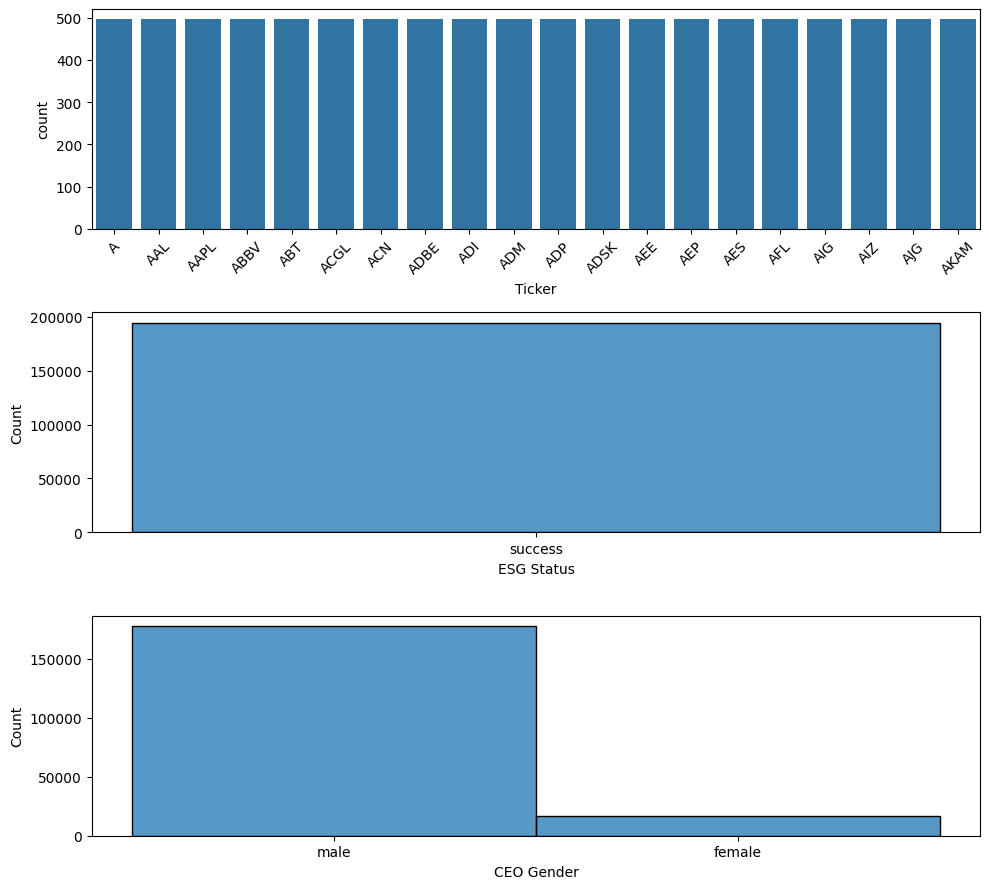

In [70]:
fig, axis = plt.subplots(3, figsize=(10, 9))

top_tickers = dataset_final["Ticker"].value_counts().nlargest(20).index
sns.countplot(ax=axis[0], data=dataset_final[dataset_final["Ticker"].isin(top_tickers)], x="Ticker")
axis[0].tick_params(axis='x', rotation=45)
sns.histplot(ax = axis[1], data = dataset_final, x = "ESG Status")
sns.histplot(ax = axis[2], data = dataset_final, x = "CEO Gender")

plt.tight_layout()
plt.show()

**Conclusions**: 

- **Ticker Distribution (Top 20)**: Among the 20 most frequent tickers, each company appears with almost identical representation (around 1,900 records each). The dataset is therefore highly balanced across companies, with no single ticker dominating the sample. This balance suggests that the data collection process ensured equal weighting between firms,

- **ESG Status**: All records show “success” as the ESG Status. There is no variation. This feature provides no predictive power (constant variable).

- **CEO Gender**: Strong imbalance: the majority of CEOs are male, with a much smaller proportion being female.

## **5. Multivariate Analysis**

### **5.1 Numerical vs Numerical Analysis**

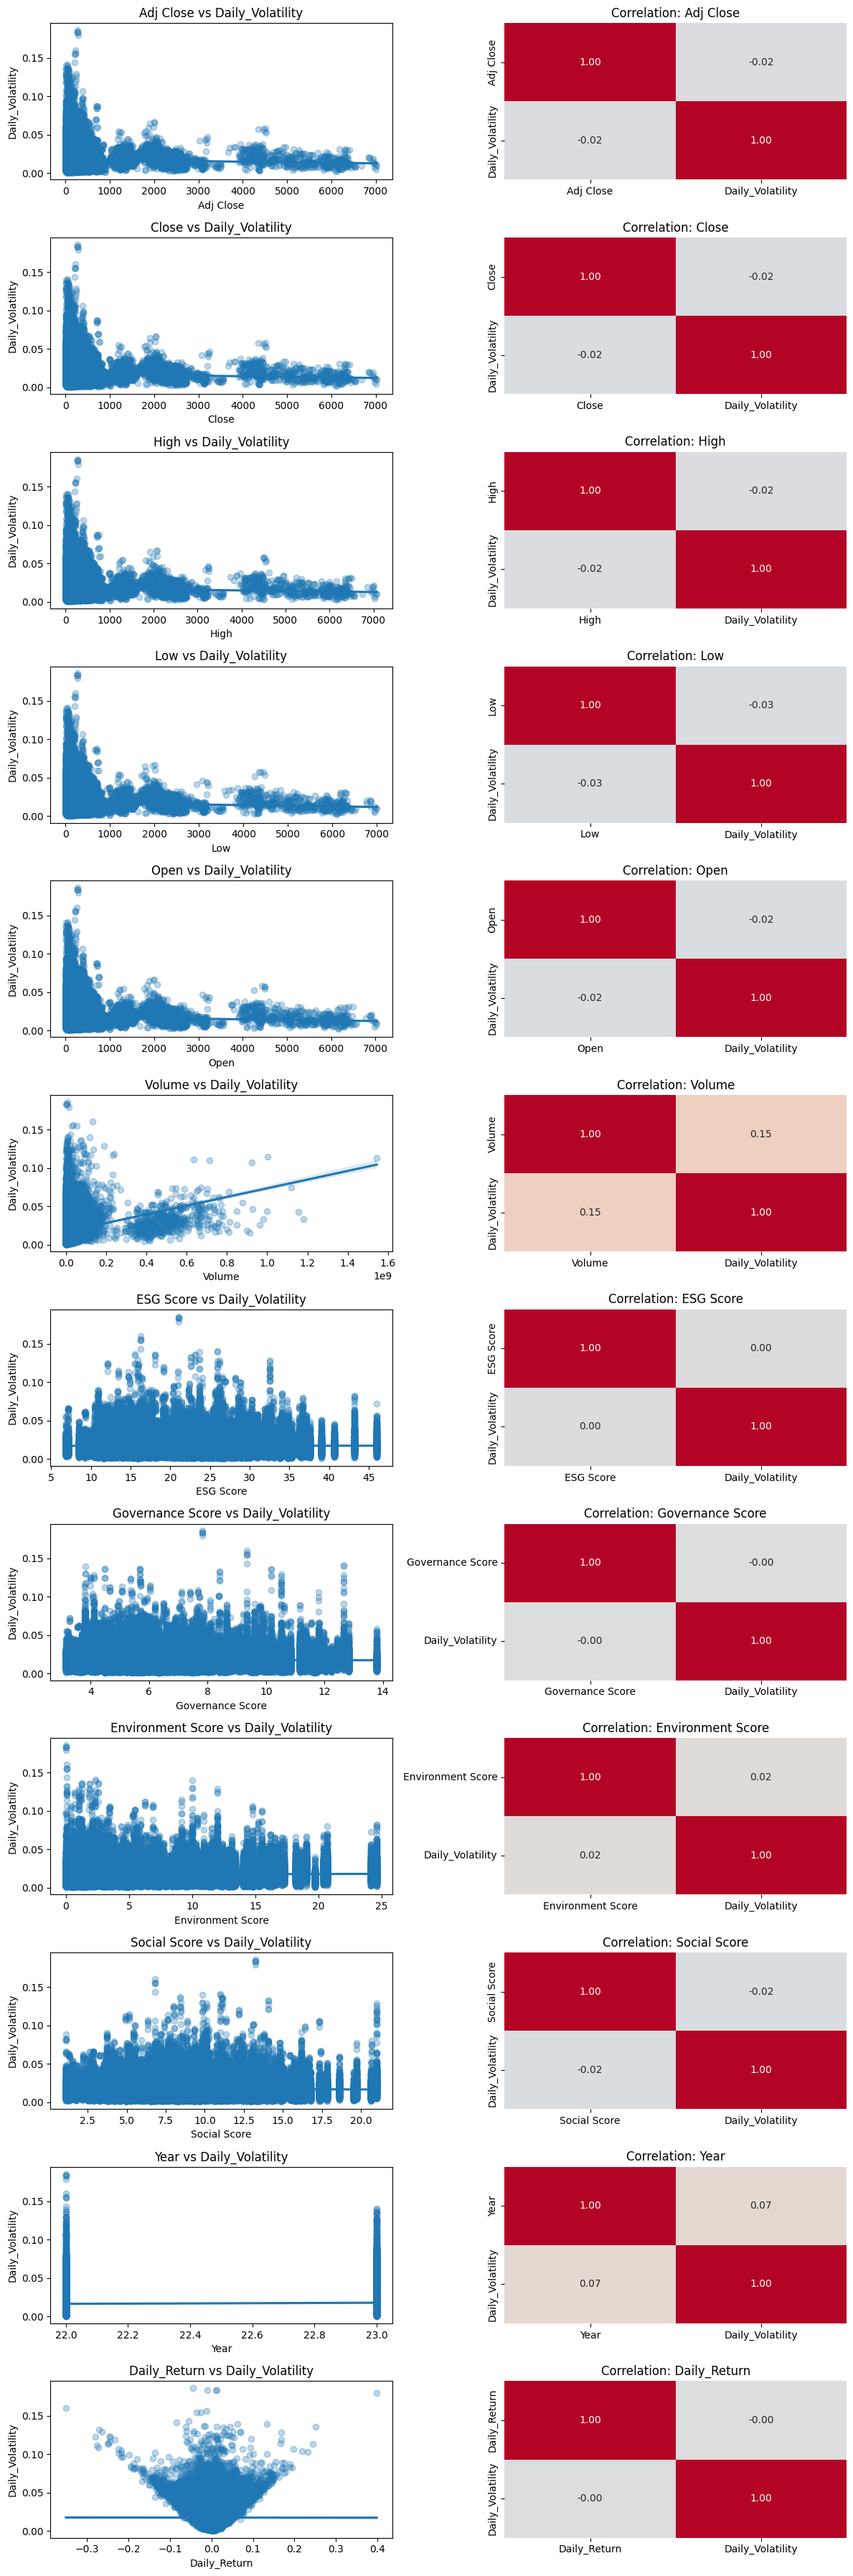

In [22]:
# Variables to compare with Daily_Volatility
variables = [
    "Adj Close", "Close", "High", "Low", "Open", "Volume",
    "ESG Score", "Governance Score", "Environment Score",
    "Social Score", "Year", "Daily_Return"
]

n_vars = len(variables)
ncols = 2   
nrows = n_vars  

fig, axes = plt.subplots(
    nrows=nrows, 
    ncols=ncols, 
    figsize=(12, nrows * 3)
)

# If there's only 1 row, convert axes to 2D to avoid errors
if nrows == 1:
    axes = [axes]

for i, var in enumerate(variables):
    # Regplot on the left
    sns.regplot(
        ax=axes[i, 0], 
        data=dataset_final, 
        x=var, 
        y="Daily_Volatility", 
        scatter_kws={"alpha": 0.3}
    )
    axes[i, 0].set_title(f"{var} vs Daily_Volatility")

    # Heatmap on the right
    corr = dataset_final[[var, "Daily_Volatility"]].corr()
    sns.heatmap(
        corr, 
        annot=True, 
        fmt=".2f", 
        ax=axes[i, 1], 
        cbar=False, 
        cmap="coolwarm",
        vmin=-1, vmax=1
    )
    axes[i, 1].set_title(f"Correlation: {var}")

plt.tight_layout()
plt.show()


**Conclusions**:

- **Price Variables (Adj Close, Close, High, Low, Open)**: All show a negative correlation (~ -0.05) with Daily Volatility. Scatterplots reveal that as stock prices increase, volatility tends to decrease slightly. This suggests that higher-priced stocks exhibit more stability, while lower-priced stocks are relatively more volatile.

- **Volume**: Shows a positive correlation (0.15) with Daily Volatility. Scatterplot indicates that higher trading volume is somewhat associated with higher volatility. This aligns with market behavior: when trading activity surges, price fluctuations intensify.

- **ESG Score**: Very weak negative correlation (-0.02) with volatility. Scatterplot shows no clear trend. ESG performance does not meaningfully explain short-term volatility.

- **Governance Score**: Very weak negative correlation (-0.03). Scatterplot shows dispersed points, no trend.

- **Environment Score**: Near-zero correlation (0.01).No visible pattern in the scatterplot. Suggests that environmental factors don’t directly affect daily volatility.

- **Social Score**: Weak negative correlation (-0.03). Similar to Governance and ESG Score — no significant relationship. Indicates social factors are not linked to short-term volatility.

- **Year**: Slight positive correlation (0.07) with volatility. Scatterplot shows changes in volatility across years, possibly due to macroeconomic events or crises. Suggests that market conditions vary across years, impacting volatility moderately.

- **Daily Return**: Very weak positive correlation (0.01) with volatility. Scatterplot shows the expected pattern: higher absolute returns often coincide with higher volatility. Indicates that price jumps (positive or negative) usually increase volatility.

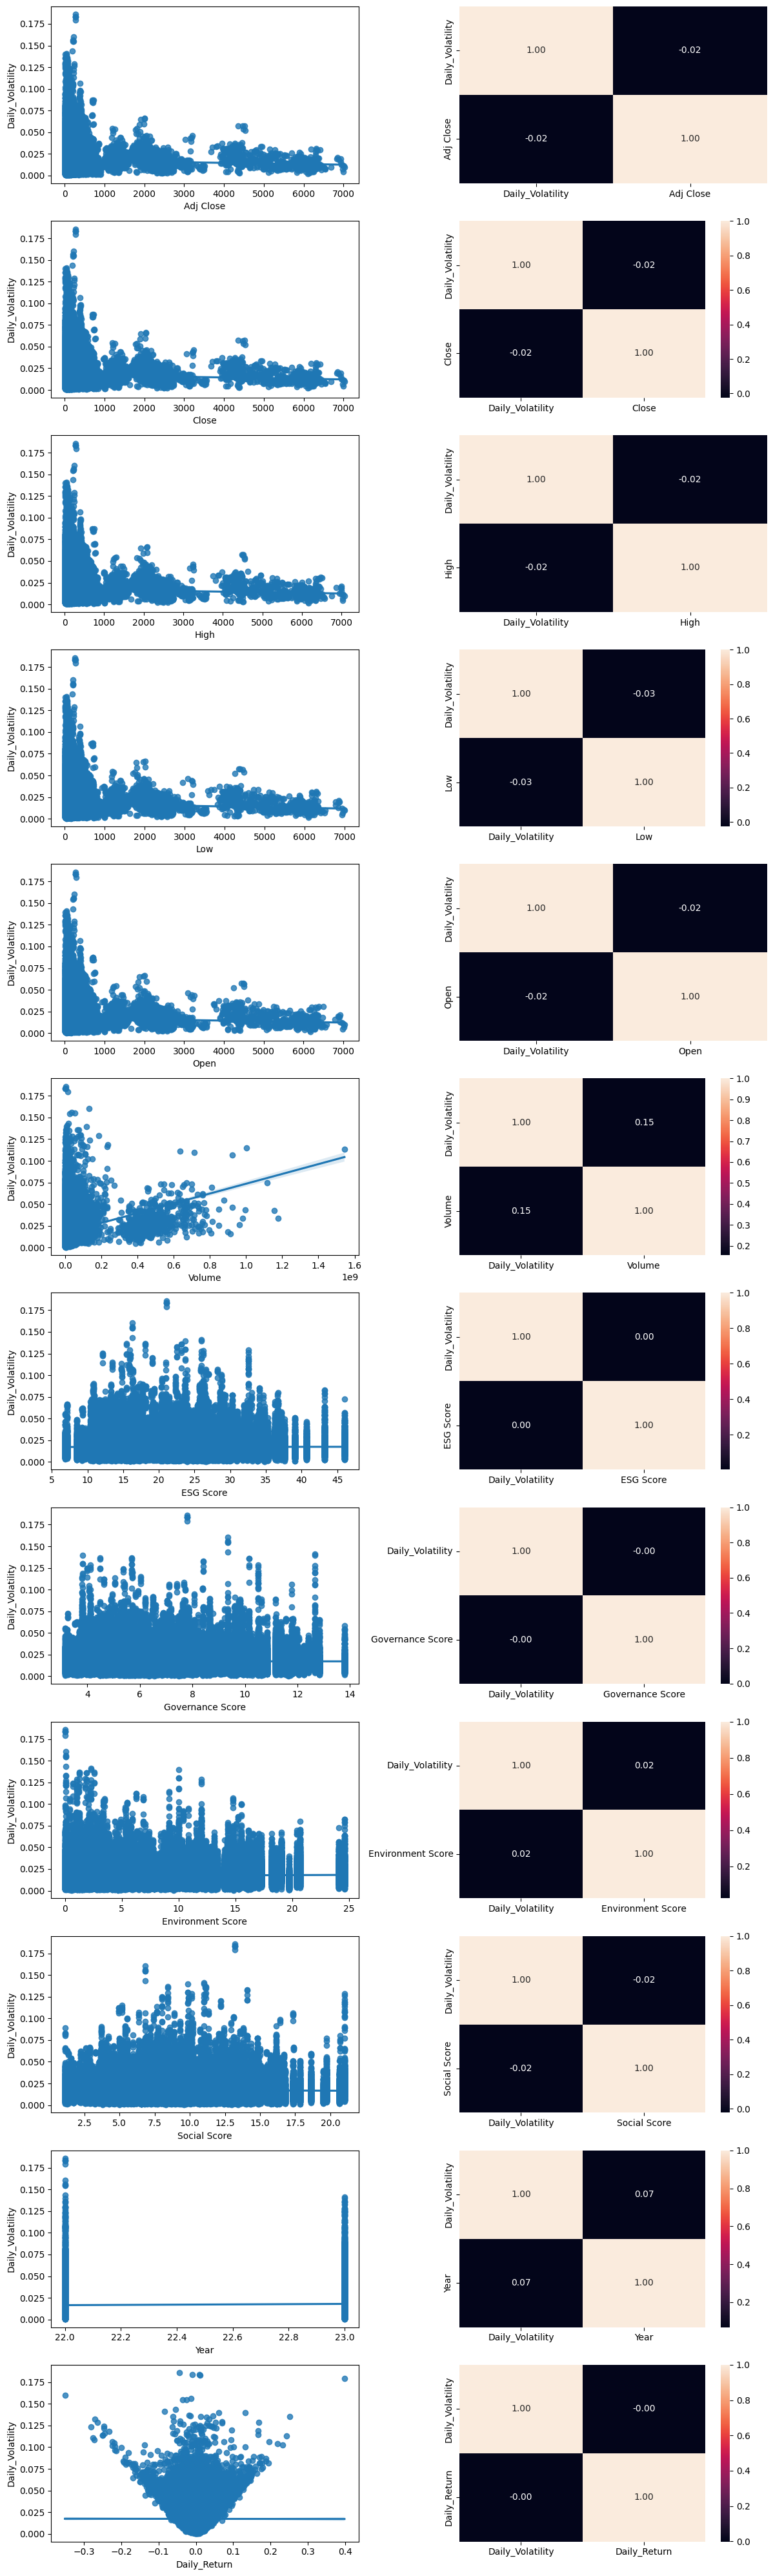

In [23]:
fig, axis = plt.subplots(12, 2, figsize=(12, 40))  # 12 variables → 12 rows x 2 columns

sns.regplot(ax=axis[0, 0], data=dataset_final, x="Adj Close", y="Daily_Volatility")
sns.heatmap(dataset_final[["Daily_Volatility", "Adj Close"]].corr(), annot=True, fmt=".2f", ax=axis[0, 1], cbar=False)

sns.regplot(ax=axis[1, 0], data=dataset_final, x="Close", y="Daily_Volatility")
sns.heatmap(dataset_final[["Daily_Volatility", "Close"]].corr(), annot=True, fmt=".2f", ax=axis[1, 1])

sns.regplot(ax=axis[2, 0], data=dataset_final, x="High", y="Daily_Volatility")
sns.heatmap(dataset_final[["Daily_Volatility", "High"]].corr(), annot=True, fmt=".2f", ax=axis[2, 1], cbar=False)

sns.regplot(ax=axis[3, 0], data=dataset_final, x="Low", y="Daily_Volatility")
sns.heatmap(dataset_final[["Daily_Volatility", "Low"]].corr(), annot=True, fmt=".2f", ax=axis[3, 1])

sns.regplot(ax=axis[4, 0], data=dataset_final, x="Open", y="Daily_Volatility")
sns.heatmap(dataset_final[["Daily_Volatility", "Open"]].corr(), annot=True, fmt=".2f", ax=axis[4, 1], cbar=False)

sns.regplot(ax=axis[5, 0], data=dataset_final, x="Volume", y="Daily_Volatility")
sns.heatmap(dataset_final[["Daily_Volatility", "Volume"]].corr(), annot=True, fmt=".2f", ax=axis[5, 1])

sns.regplot(ax=axis[6, 0], data=dataset_final, x="ESG Score", y="Daily_Volatility")
sns.heatmap(dataset_final[["Daily_Volatility", "ESG Score"]].corr(), annot=True, fmt=".2f", ax=axis[6, 1])

sns.regplot(ax=axis[7, 0], data=dataset_final, x="Governance Score", y="Daily_Volatility")
sns.heatmap(dataset_final[["Daily_Volatility", "Governance Score"]].corr(), annot=True, fmt=".2f", ax=axis[7, 1])

sns.regplot(ax=axis[8, 0], data=dataset_final, x="Environment Score", y="Daily_Volatility")
sns.heatmap(dataset_final[["Daily_Volatility", "Environment Score"]].corr(), annot=True, fmt=".2f", ax=axis[8, 1])

sns.regplot(ax=axis[9, 0], data=dataset_final, x="Social Score", y="Daily_Volatility")
sns.heatmap(dataset_final[["Daily_Volatility", "Social Score"]].corr(), annot=True, fmt=".2f", ax=axis[9, 1])

sns.regplot(ax=axis[10, 0], data=dataset_final, x="Year", y="Daily_Volatility")
sns.heatmap(dataset_final[["Daily_Volatility", "Year"]].corr(), annot=True, fmt=".2f", ax=axis[10, 1])

sns.regplot(ax=axis[11, 0], data=dataset_final, x="Daily_Return", y="Daily_Volatility")
sns.heatmap(dataset_final[["Daily_Volatility", "Daily_Return"]].corr(), annot=True, fmt=".2f", ax=axis[11, 1])

plt.tight_layout()
plt.show()


**Conclusions**:

- **Prices Variables (Adj Close, Close, High, Low, Open)**: Show a very weak negative correlation (-0.05) with daily volatility.Scatterplots suggest that higher stock prices are slightly associated with lower volatility. In short: higher-priced stocks appear more stable, but the relationship is weak.

- **Volume**: Displays the strongest positive correlation (0.15) with daily volatility. Higher trading activity tends to come with higher volatility. This is consistent with financial theory: increased market activity often leads to greater price fluctuations.

- **ESG Scores (ESG, Governance, Environment, Social)**: All correlations are close to zero (between -0.02 and -0.03).Scatterplots show no clear pattern. ESG factors do not exhibit a noticeable linear relationship with daily volatility.

- **Year**: Shows a very small positive correlation (0.07) with daily volatility. This suggests that volatility has varied slightly over time, possibly due to crises, regulatory changes, or macroeconomic shocks.

- **Daily Return**: Correlation is nearly zero (0.01), but the scatterplot reveals an important insight, extreme returns (large positive or negative) tend to coincide with higher volatility. This indicates the relationship is non-linear, but expected: sharp price movements usually bring higher volatility.

### **5.2 Categorical vs Categorical Analysis**

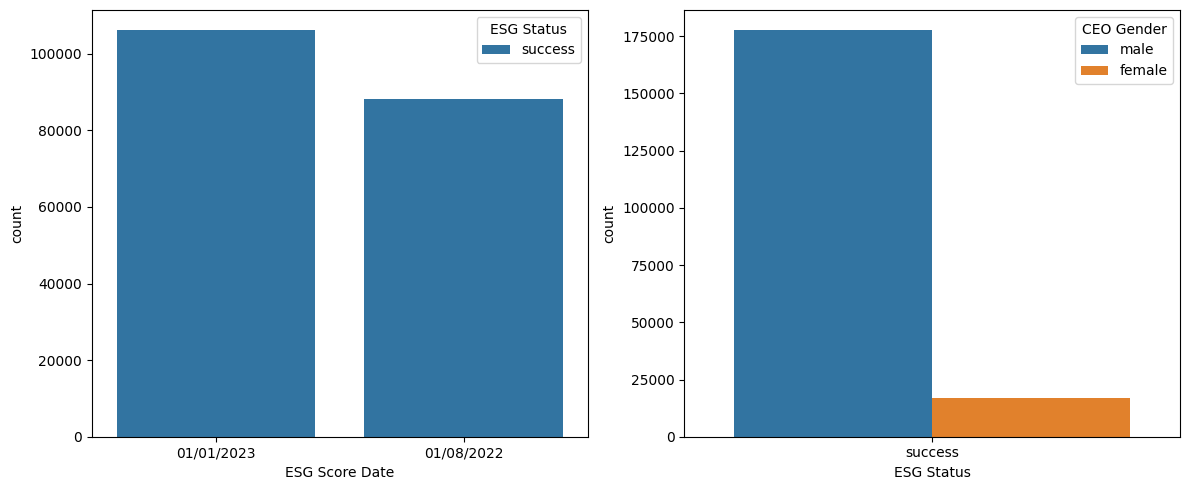

In [74]:
fig, axis = plt.subplots(1, 2, figsize=(12, 5))  

sns.countplot(data=dataset_final, x="ESG Score Date", hue="ESG Status", ax=axis[0])
sns.countplot(data=dataset_final, x="ESG Status", hue="CEO Gender", ax=axis[1])

plt.tight_layout()
plt.show()


**Conclusions**:

- The bottom plot shows the relationship between ESG Status and CEO Gender. Given that ESG Status is uniform, this plot highlights the severe imbalance in the CEO Gender category. The dataset contains a significantly larger number of entries for male CEOs compared to female CEOs

<Axes: xlabel='CEO Gender', ylabel='Daily_Volatility'>

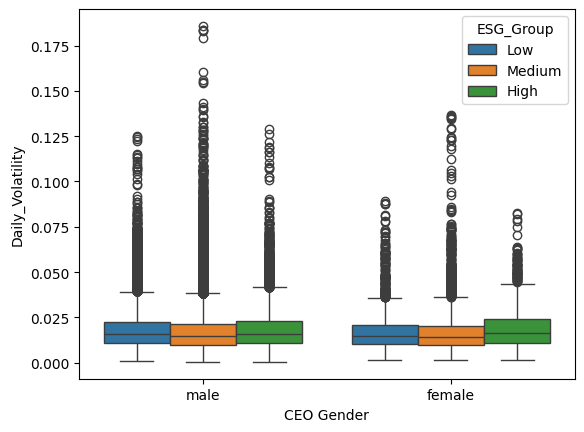

In [25]:
dataset_final["ESG_Group"] = pd.cut(dataset_final["ESG Score"], bins=[0,15,30,45], labels=["Low","Medium","High"])
sns.boxplot(data=dataset_final, x="CEO Gender", y="Daily_Volatility", hue="ESG_Group")

**Conclusions**:

- **Daily Volatility across CEO Gender**: Both male- and female-led firms exhibit broadly similar levels of daily volatility. There is no substantial difference in the median or interquartile ranges between the two groups.

- **Effect of ESG Score Grouping**: Within each gender, the distribution of volatility does not vary greatly between the Low, Medium, and High ESG groups. The medians are close, and the spread of values is largely overlapping.

- **Outliers**: A considerable number of outliers are present in both genders and across ESG groups, indicating that while most firms cluster within a narrow volatility range, some experience unusually high daily fluctuations.

Neither CEO gender nor ESG grouping appears to drive a major shift in daily volatility, suggesting that other factors may play a more decisive role in determining stock price stability.

### **5.3 Encoding Categorical Values and Saving JSON files**

In [20]:
categorical_f_rules = {}

for col in categorical_variables:
    encoded_col = f"{col}_n"
    dataset_final[encoded_col], uniques = pd.factorize(dataset_final[col])
    dicc = dict(zip(uniques, range(len(uniques))))
    categorical_f_rules[col] = dicc

with open("categorical_rules.json", "w") as f:
    json.dump(categorical_f_rules, f)

with open("categorical_rules.json", "r") as f:
    loaded_mappings = json.load(f)

dataset_final.head()

,Date,Ticker,Adj Close,Close,High,Low,Open,Volume,ESG Score,Governance Score,...,ESG Score Date,ESG Status,CEO Gender,Year,Daily_Return,Daily_Volatility,Ticker_n,ESG Score Date_n,ESG Status_n,CEO Gender_n
2000,2022-01-10,A,141.584732,145.160004,145.309998,140.860001,143.289993,2548100.0,15.24,6.26,...,01/01/2023,success,male,23,0.000069,0.016297,0,0,0,0
2001,2022-01-10,AAL,18.790001,18.790001,19.389999,18.680000,19.240000,25707700.0,29.10,5.26,...,01/01/2023,success,male,23,-0.025415,0.025821,1,0,0,0
2002,2022-01-10,AAPL,168.815567,172.190002,172.500000,168.169998,169.080002,106765600.0,16.68,9.18,...,01/08/2022,success,male,22,0.000116,0.011682,2,1,0,0
2003,2022-01-10,ABBV,118.463669,136.389999,136.899994,134.570007,135.080002,9794400.0,27.84,9.95,...,01/08/2022,success,male,22,0.011195,0.006615,3,1,0,0
2004,2022-01-10,ABT,126.047203,135.259995,135.500000,133.919998,134.789993,5975600.0,24.98,8.36,...,01/08/2022,success,male,22,-0.002213,0.010479,4,1,0,0


### **5.4 Correlation analysis**

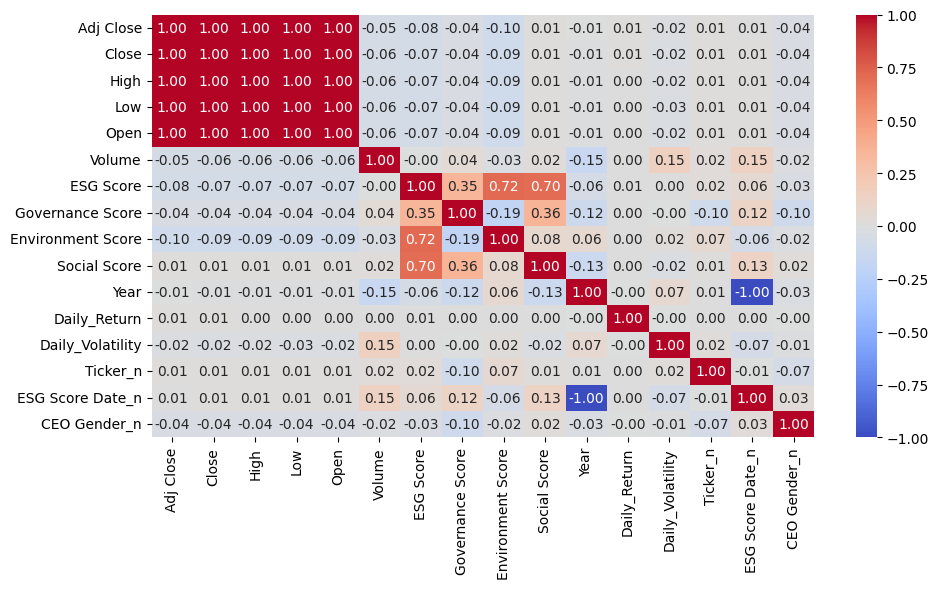

In [76]:
fig, axis = plt.subplots(figsize=(10, 6))

sns.heatmap(
    dataset_final[[
        "Adj Close", "Close", "High", "Low", "Open", "Volume",
        "ESG Score", "Governance Score", "Environment Score", "Social Score",
        "Year", "Daily_Return", "Daily_Volatility",
        "Ticker_n", "ESG Score Date_n",
        "CEO Gender_n"
    ]].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.tight_layout()
plt.show()


**Conclusions**:

- **Stock Price Variables**: Adjusted Close, Close, High, Low, and Open are almost perfectly correlated (correlation ≈ 1.00), which is expected since they are all highly related measures of stock price.

- **Volume**: Trading volume shows very weak negative correlations with price variables and ESG metrics, suggesting little direct relationship.

- **ESG Score Components**: The overall ESG Score is strongly correlated with the Environment (0.72) and Social (0.70) sub-scores, while Governance contributes less strongly (0.35). This indicates that environmental and social factors dominate the overall ESG measure in this dataset.

- **ESG vs Market Variables**: ESG scores display only weak correlations with financial metrics such as returns and volatility, implying limited direct linkage between ESG ratings and short-term market performance.

- **Outliers in Correlation**: The variable Year is negatively correlated with Environment (–0.12) and Social (–0.13), hinting at possible temporal variation in ESG scoring practices.

- **Categorical Encodings**: Numerical encodings for Ticker, ESG Score Date, and CEO Gender show negligible correlations with other variables, as expected since these are identifiers or categorical transformations.

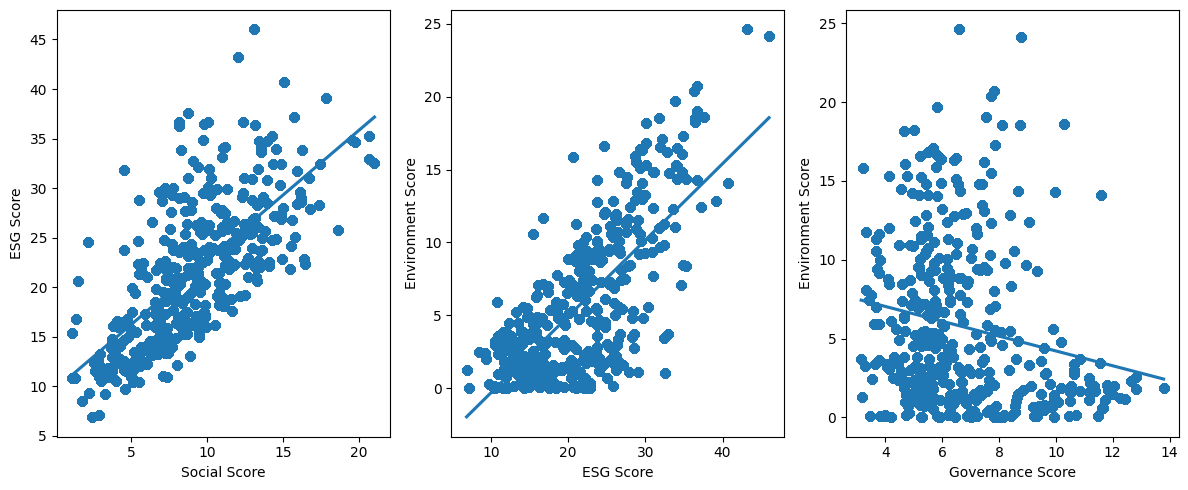

In [78]:
fig, axis = plt.subplots(figsize = (12, 5), ncols = 3)
sns.regplot(ax = axis[0], data = dataset_final, x = "Social Score", y = "ESG Score")
sns.regplot(ax = axis[1], data = dataset_final, x = "ESG Score", y = "Environment Score")
sns.regplot(ax = axis[2], data = dataset_final, x = "Governance Score", y = "Environment Score")

plt.tight_layout()
plt.show()

**Conclusions**:

- **Social Score vs. ESG Score**: The plot of Social Score against ESG Score shows a strong positive correlation. As Social Score is a direct component of the overall ESG Score, a strong positive linear relationship is expected. This means that as a company's social performance improves, its overall ESG score tends to increase significantly.

- **ESG Score vs. Environment Score**: Similarly, the plot of ESG Score against Environment Score would also show a strong positive correlation. This indicates that environmental performance is a major contributor to a company's overall ESG score. A company with a high environmental score is likely to also have a high overall ESG score.

- **Governance Score vs. Environment Score**: The plot of Governance Score against Environment Score reveals a weak negative relationship. This is a fascinating and unexpected finding. It suggests that companies with a higher Governance Score may, on average, have a lower Environment Score.

## **6. Analysing all the Data at Once**


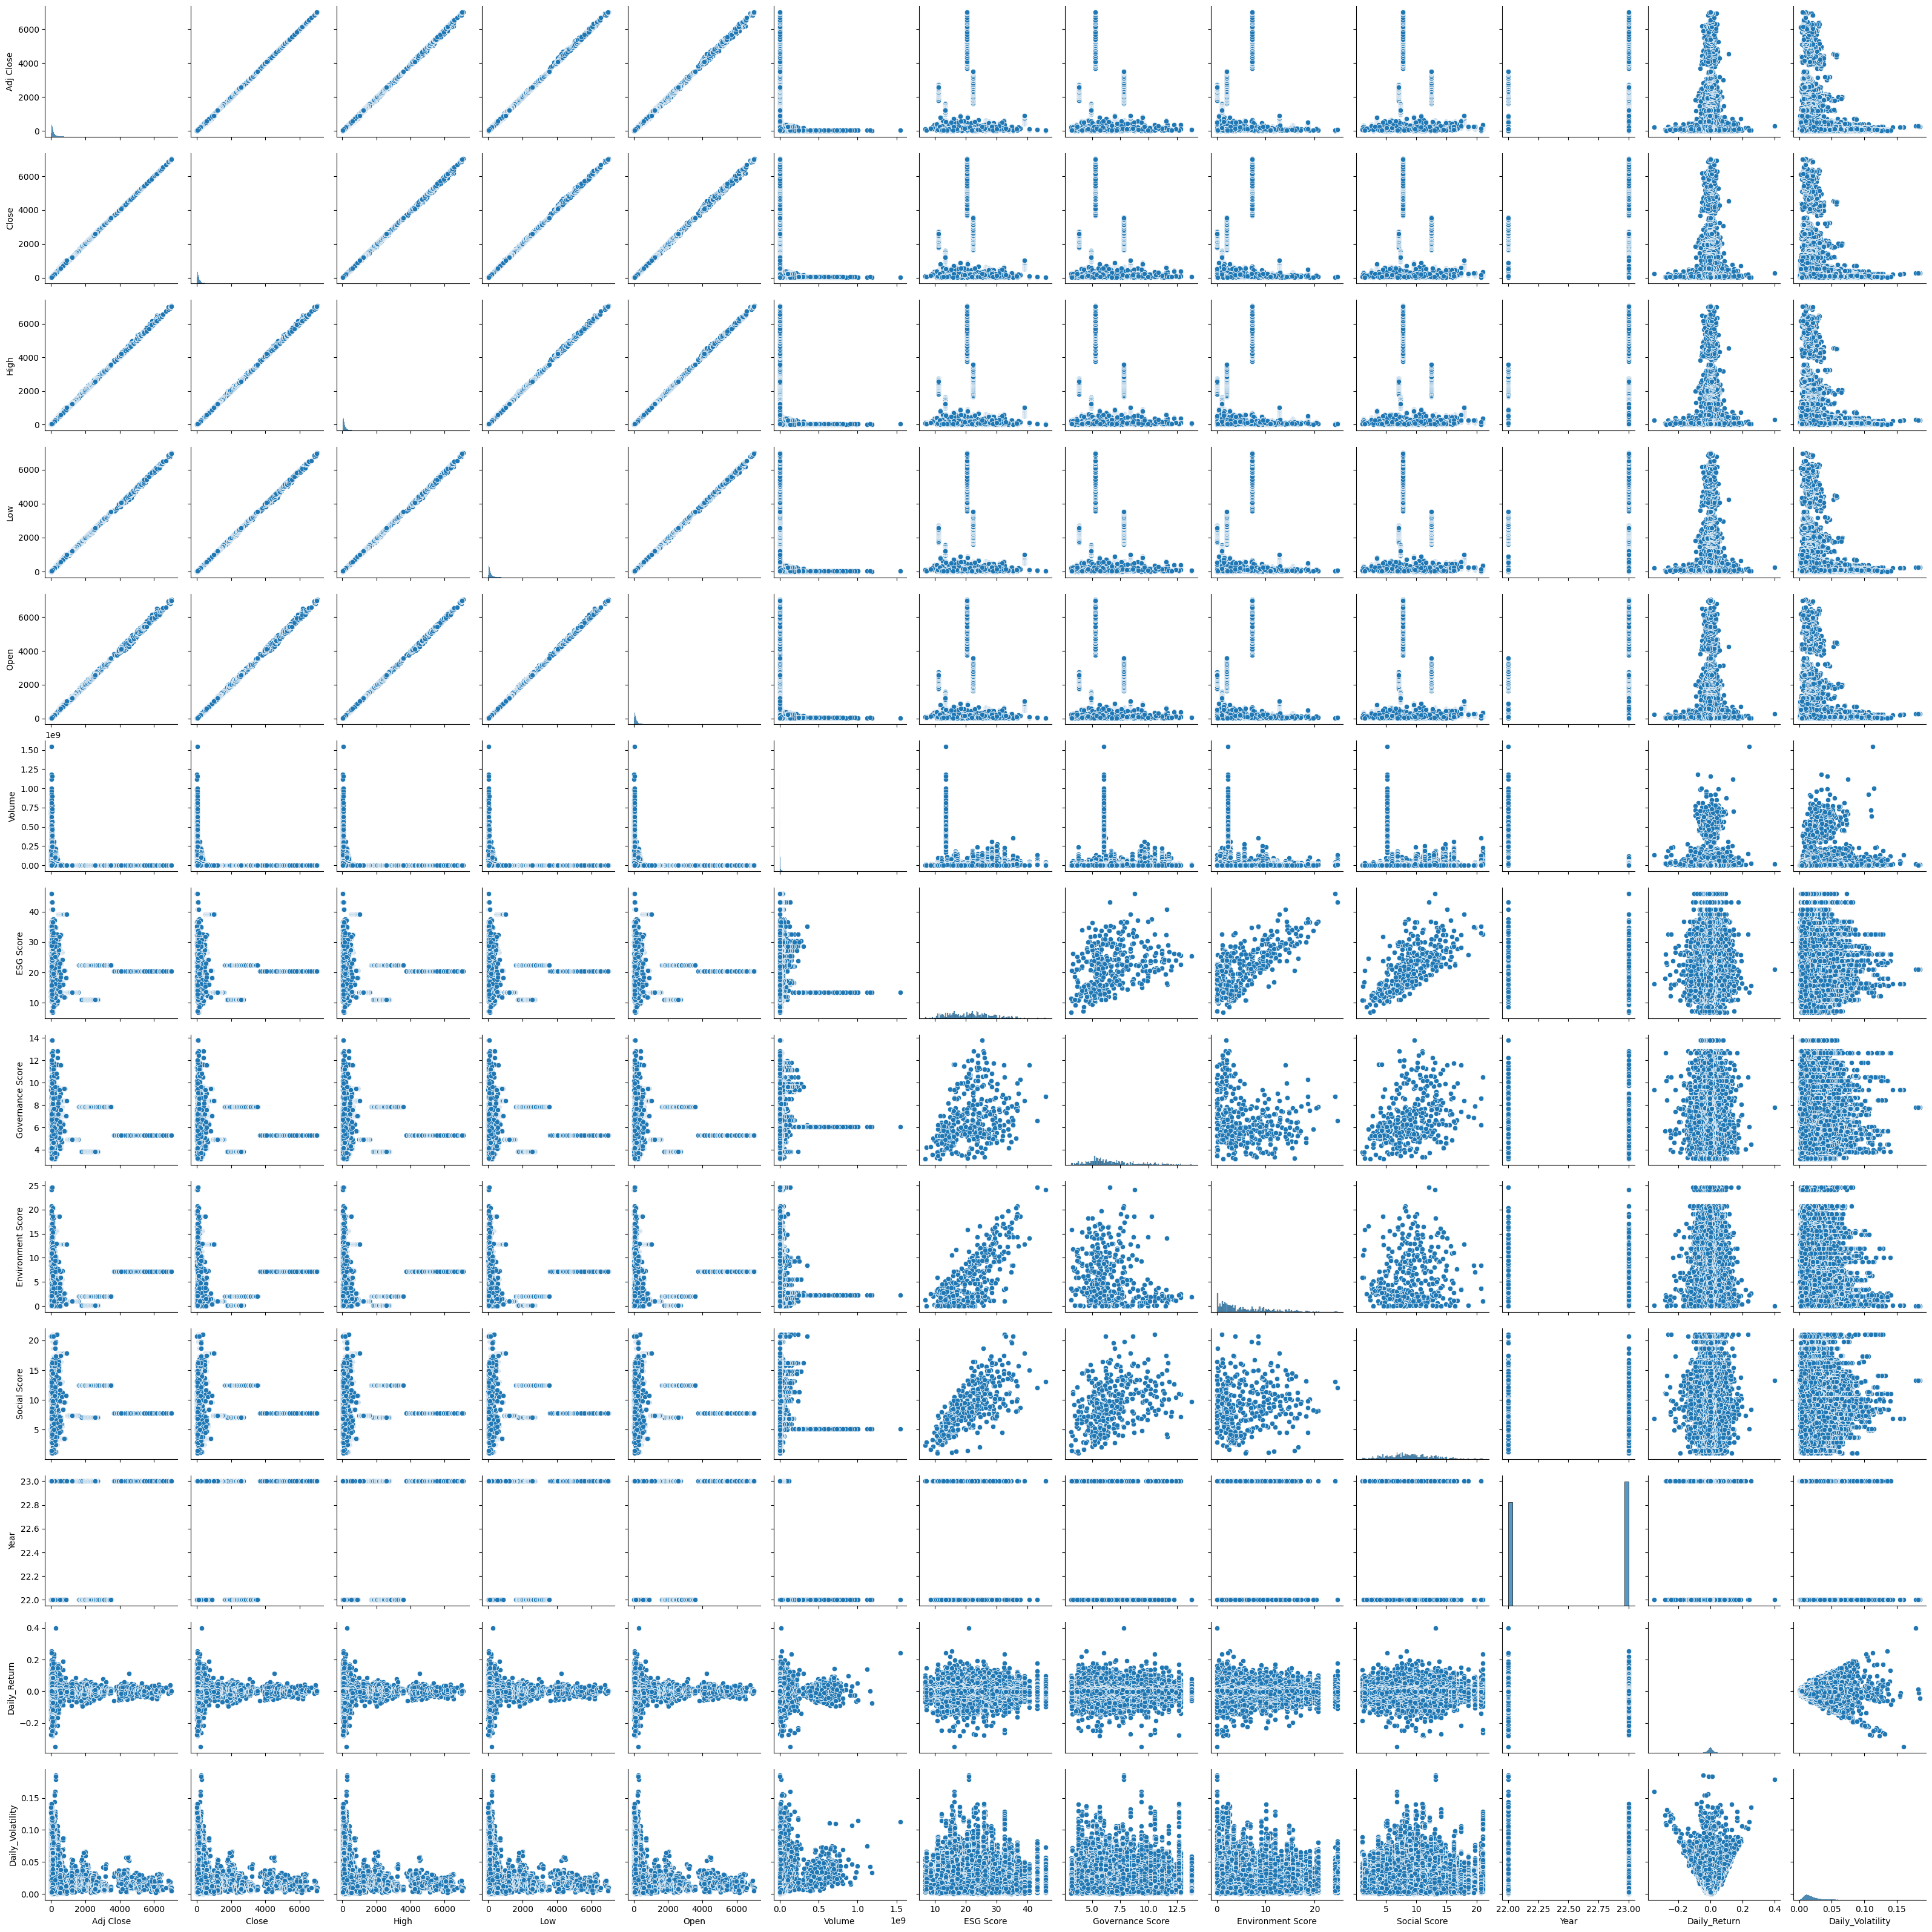

In [16]:
sns.pairplot(data = dataset_final)

**Conclusions**:

The diagonal plots confirm the distributions seen in previous plots:

Daily_Return and Daily_Volatility have highly skewed distributions with a strong concentration of data around zero. The long tails indicate the presence of significant outliers, which are common and meaningful in financial data.

ESG Score has a more spread-out distribution, with a wider range of values.

Volume is extremely skewed, with most data points clustered at low values and a long tail of outliers representing days with very high trading activity.

In [21]:
dataset_final.describe()

,Date,Adj Close,Close,High,Low,Open,Volume,ESG Score,Governance Score,Environment Score,Social Score,Year,Daily_Return,Daily_Volatility,Ticker_n,ESG Score Date_n,ESG Status_n,CEO Gender_n
count,194432,194432.000000,194432.000000,194432.000000,194432.000000,194432.000000,1.944320e+05,194432.000000,194432.000000,194432.000000,194432.000000,194432.000000,194432.000000,194432.000000,194432.000000,194432.000000,194432.0,194432.000000
mean,2023-01-04 06:52:15.483870720,160.937325,167.388926,169.368992,165.331806,167.345709,6.552061e+06,21.568444,6.717755,5.755510,9.095230,22.545918,0.000226,0.017352,195.500000,0.454082,0.0,0.086735
min,2022-01-10 00:00:00,6.380000,6.380000,6.740000,6.110000,6.420000,6.400000e+03,6.840000,3.150000,0.000000,1.110000,22.000000,-0.351166,0.000479,0.000000,0.000000,0.0,0.000000
25%,2022-07-10 06:00:00,54.929926,58.689999,59.419998,57.950001,58.709999,1.071500e+06,15.940000,5.250000,1.595000,6.647500,22.000000,-0.010177,0.010248,97.750000,0.000000,0.0,0.000000
50%,2023-01-04 12:00:00,95.648376,101.309998,102.559998,99.980003,101.260002,2.154600e+06,21.435000,6.205000,3.820000,8.810000,23.000000,0.000344,0.014978,195.500000,0.000000,0.0,0.000000
75%,2023-07-05 06:00:00,172.638763,181.679993,183.779999,179.509995,181.639999,4.925325e+06,26.242500,7.722500,9.215000,11.462500,23.000000,0.010650,0.021751,293.250000,1.000000,0.0,0.000000
max,2023-12-29 00:00:00,7024.819824,7024.819824,7075.000000,6997.910156,7028.500000,1.543911e+09,46.020000,13.790000,24.610000,21.010000,23.000000,0.398503,0.185806,391.000000,1.000000,0.0,1.000000
std,NaN,331.432627,332.953698,336.914249,328.891816,332.770562,2.884069e+07,7.112719,2.142073,5.206709,3.787409,0.497888,0.020220,0.010542,113.160576,0.497888,0.0,0.281447


## **7. Feature Engineering**

### **7.1 Outliers analysis**

In [22]:
dataset_final.describe()

,Date,Adj Close,Close,High,Low,Open,Volume,ESG Score,Governance Score,Environment Score,Social Score,Year,Daily_Return,Daily_Volatility,Ticker_n,ESG Score Date_n,ESG Status_n,CEO Gender_n
count,194432,194432.000000,194432.000000,194432.000000,194432.000000,194432.000000,1.944320e+05,194432.000000,194432.000000,194432.000000,194432.000000,194432.000000,194432.000000,194432.000000,194432.000000,194432.000000,194432.0,194432.000000
mean,2023-01-04 06:52:15.483870720,160.937325,167.388926,169.368992,165.331806,167.345709,6.552061e+06,21.568444,6.717755,5.755510,9.095230,22.545918,0.000226,0.017352,195.500000,0.454082,0.0,0.086735
min,2022-01-10 00:00:00,6.380000,6.380000,6.740000,6.110000,6.420000,6.400000e+03,6.840000,3.150000,0.000000,1.110000,22.000000,-0.351166,0.000479,0.000000,0.000000,0.0,0.000000
25%,2022-07-10 06:00:00,54.929926,58.689999,59.419998,57.950001,58.709999,1.071500e+06,15.940000,5.250000,1.595000,6.647500,22.000000,-0.010177,0.010248,97.750000,0.000000,0.0,0.000000
50%,2023-01-04 12:00:00,95.648376,101.309998,102.559998,99.980003,101.260002,2.154600e+06,21.435000,6.205000,3.820000,8.810000,23.000000,0.000344,0.014978,195.500000,0.000000,0.0,0.000000
75%,2023-07-05 06:00:00,172.638763,181.679993,183.779999,179.509995,181.639999,4.925325e+06,26.242500,7.722500,9.215000,11.462500,23.000000,0.010650,0.021751,293.250000,1.000000,0.0,0.000000
max,2023-12-29 00:00:00,7024.819824,7024.819824,7075.000000,6997.910156,7028.500000,1.543911e+09,46.020000,13.790000,24.610000,21.010000,23.000000,0.398503,0.185806,391.000000,1.000000,0.0,1.000000
std,NaN,331.432627,332.953698,336.914249,328.891816,332.770562,2.884069e+07,7.112719,2.142073,5.206709,3.787409,0.497888,0.020220,0.010542,113.160576,0.497888,0.0,0.281447


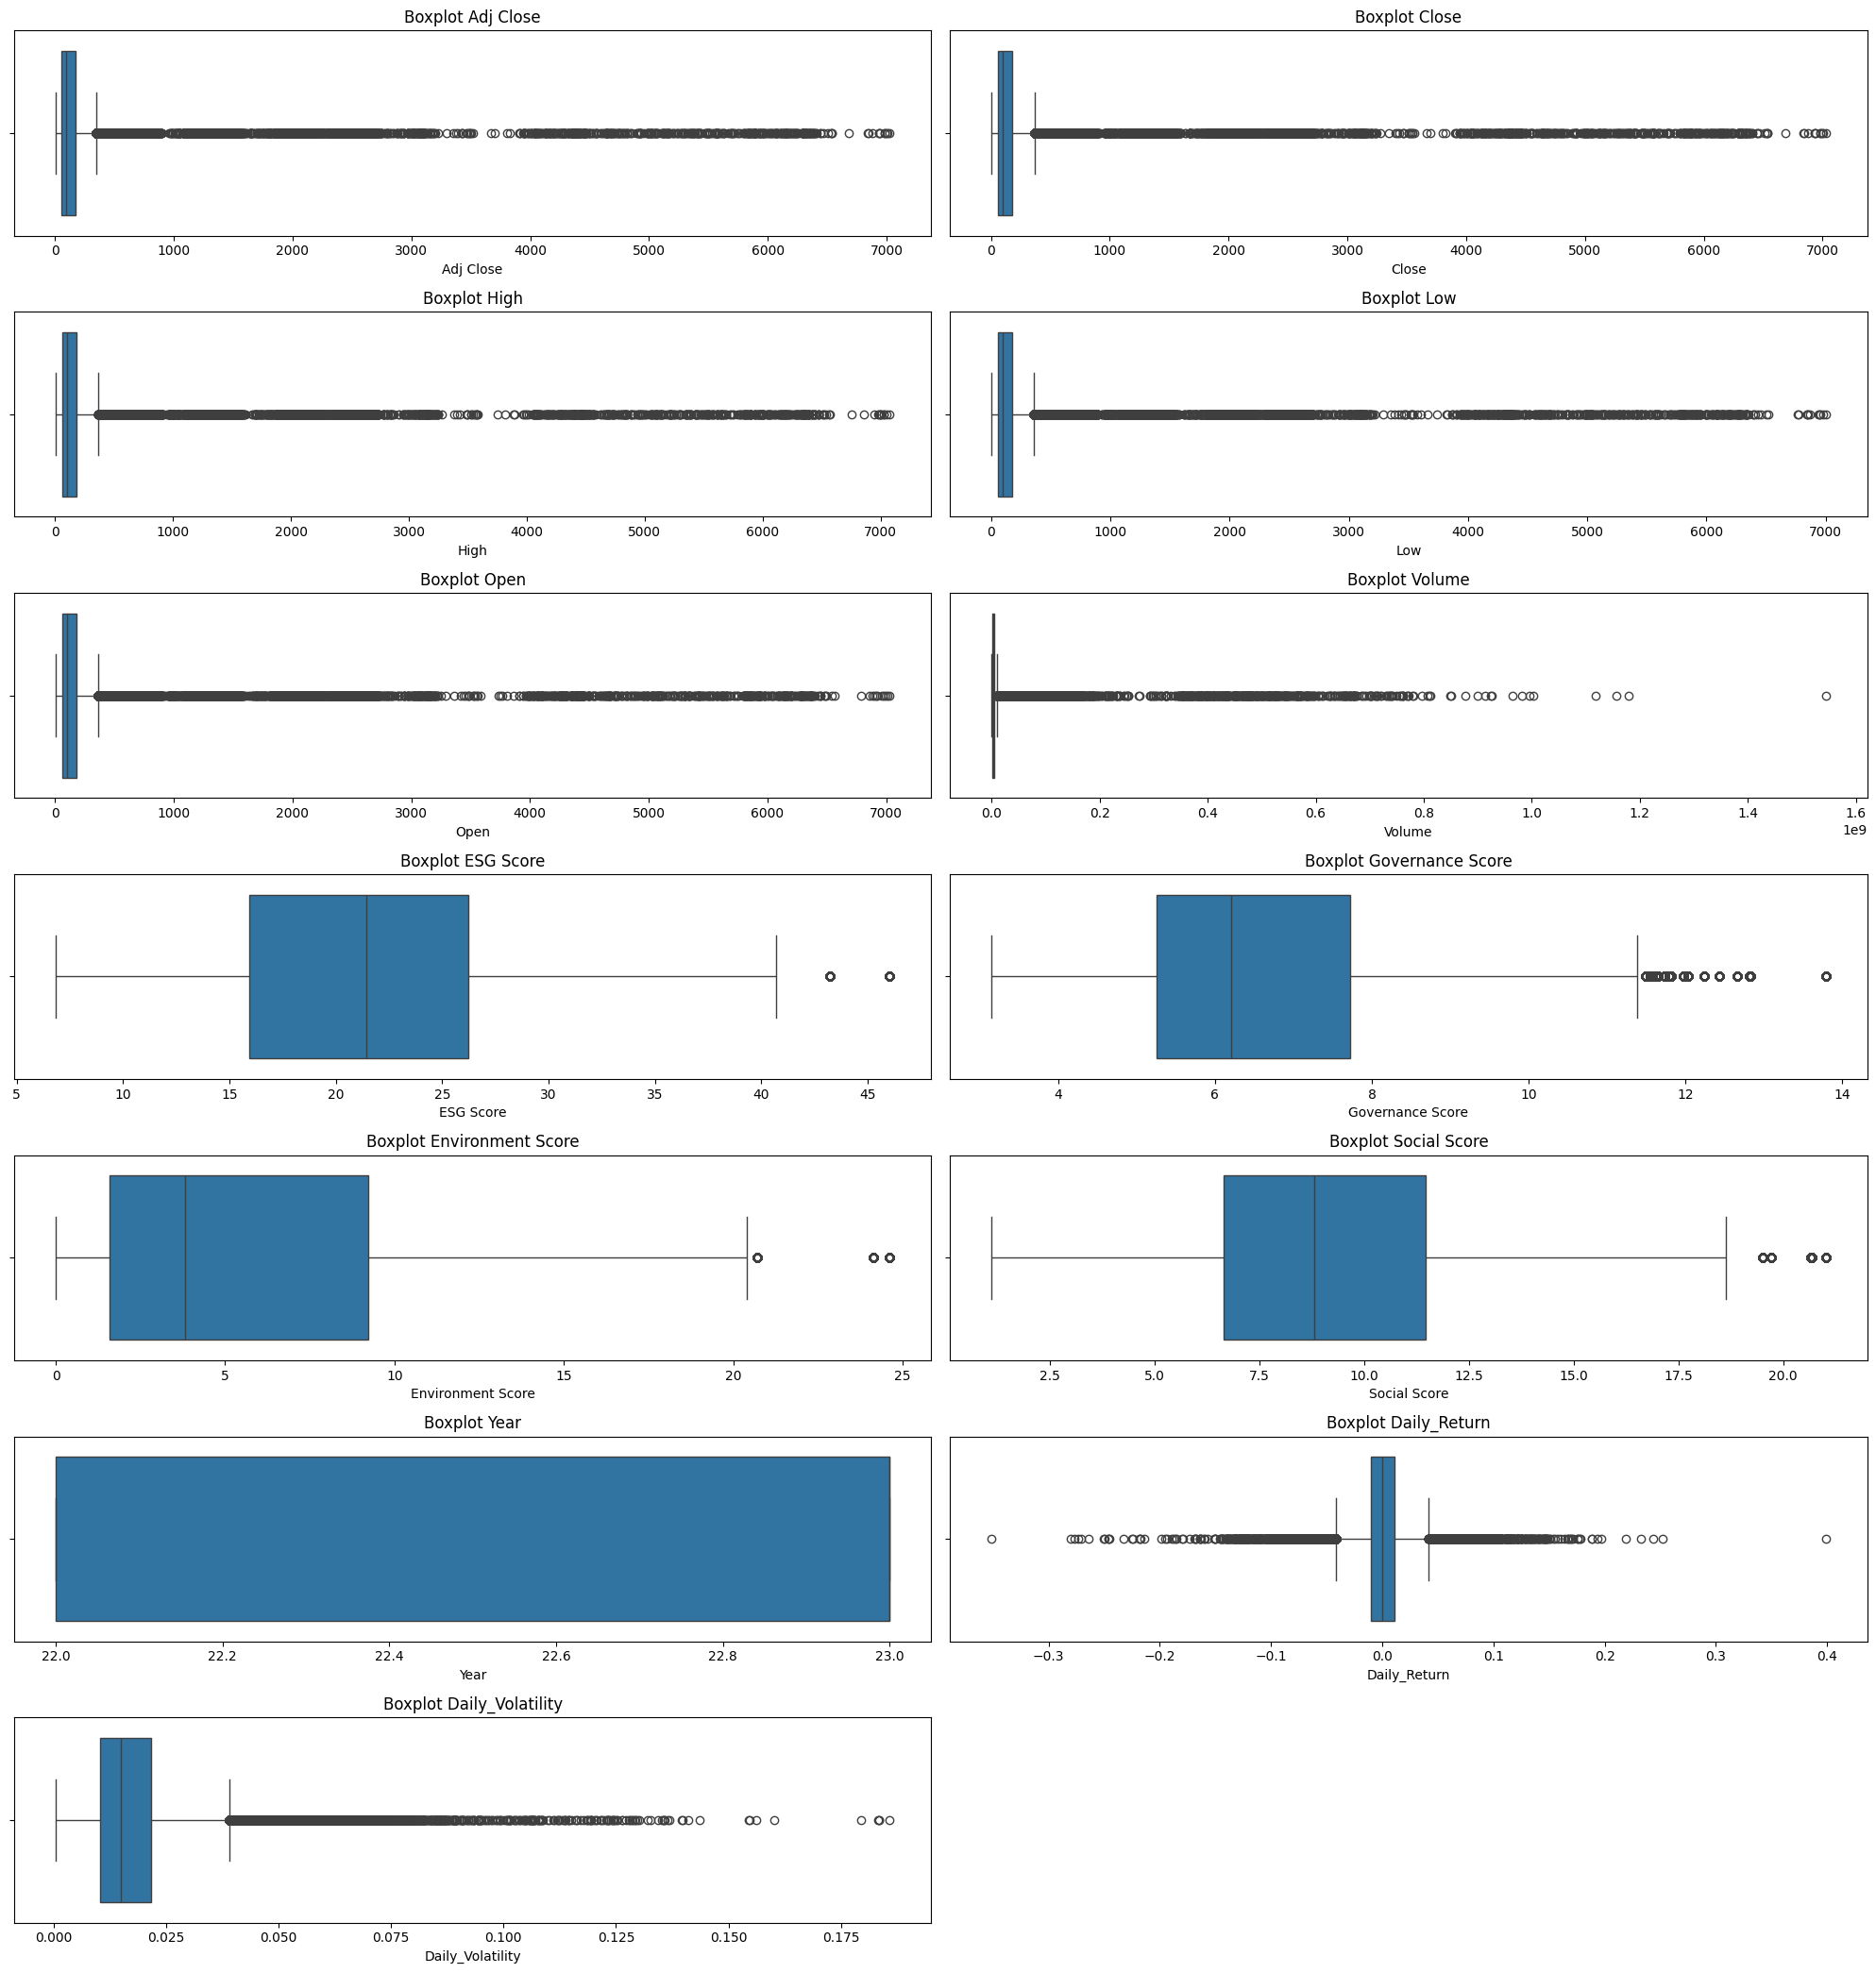

In [32]:
numerical_variables 
num_vars = len(numerical_variables)
ncols = 2
nrows = num_vars // ncols + (num_vars % ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(20, nrows * 3)
)

axes = axes.flatten()
for i, var in enumerate(numerical_variables):
    sns.boxplot(data=dataset_final, x=var, ax=axes[i])
    axes[i].set_title(f"Boxplot {var}")
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

**Conclusions**:

- **Prices Variables (Adj Close, Close, High, Low, Open)**: All show a very high number of outliers. This is normal in financial data, these outliers are not errors but rather represent large, genuine price swings driven by market events, news, or investor behavior.

- **Volume**: It has an extremely skewed distribution with a vast number of outliers. The box itself is very compressed at the lower end, indicating that most trading days have a relatively low volume. The outliers, which can be millions or even billions of shares, represent days with unusually high trading activity.

- **ESG Scores**: The ESG Score, Governance Score, and Social Score plots show a more contained distribution with fewer outliers. The Environment Score, however, appears to have a higher number of outliers at the upper end of the scale. This suggests that while most companies have similar environmental scores, there are a few outlier companies with exceptionally high scores. 

- **Daily Return and Daily Volatility**: Show a large number of outliers. These are not data entry errors but are genuine, high-impact data points representing days with extreme market behavior. 

- **Ticker_n, ESG ScoreDate_n, and Esg Status_n**: These are likely numerical representations of categorical variables. They simply show the spread of the numerical codes assigned to each category, which is not statistically meaningful in the same way as for continuous variables. 

### **7.2 Remove outliers**


In [23]:
numerical_columns = [
   'Adj Close', 
   'Close', 
   'High', 
   'Low', 
   'Open', 
   'Volume', 
   'ESG Score',
   'Governance Score', 
   'Environment Score', 
   'Social Score', 
   'Year',
   'Daily_Return'
]

for column in numerical_columns:
    stats = dataset_final[column].describe()
    iqr = stats["75%"] - stats["25%"]
    upper_limit = stats["75%"] + 1.5 * iqr
    lower_limit = stats["25%"] - 1.5 * iqr
    if lower_limit < 0:
      lower_limit = 0
    
    outliers = dataset_final[(dataset_final[column] < lower_limit) | (dataset_final[column] > upper_limit)]
    outlier_count = outliers.shape[0]

    print(f"{column.capitalize()} — IQR: {round(iqr, 2)}, Upper limits: {round(upper_limit, 2)}, Lowerlimits: {round(lower_limit, 2)}")
    print(f"Total de outliers: {outlier_count}\n")

Adj close — IQR: 117.71, Upper limits: 349.2, Lowerlimits: 0
Total de outliers: 15471

Close — IQR: 122.99, Upper limits: 366.16, Lowerlimits: 0
Total de outliers: 14745

High — IQR: 124.36, Upper limits: 370.32, Lowerlimits: 0
Total de outliers: 14775

Low — IQR: 121.56, Upper limits: 361.85, Lowerlimits: 0
Total de outliers: 14697

Open — IQR: 122.93, Upper limits: 366.03, Lowerlimits: 0
Total de outliers: 14730

Volume — IQR: 3853825.0, Upper limits: 10706062.5, Lowerlimits: 0
Total de outliers: 20270

Esg score — IQR: 10.3, Upper limits: 41.7, Lowerlimits: 0.49
Total de outliers: 992

Governance score — IQR: 2.47, Upper limits: 11.43, Lowerlimits: 1.54
Total de outliers: 7936

Environment score — IQR: 7.62, Upper limits: 20.64, Lowerlimits: 0
Total de outliers: 1488

Social score — IQR: 4.82, Upper limits: 18.69, Lowerlimits: 0
Total de outliers: 2480

Year — IQR: 1.0, Upper limits: 24.5, Lowerlimits: 20.5
Total de outliers: 0

Daily_return — IQR: 0.02, Upper limits: 0.04, Lowerlim

In [24]:
dataset_final.isnull().sum().sort_values(ascending=False) / len(dataset_final)

Date                 0.0
Ticker               0.0
Adj Close            0.0
Close                0.0
High                 0.0
Low                  0.0
Open                 0.0
Volume               0.0
ESG Score            0.0
Governance Score     0.0
Environment Score    0.0
Social Score         0.0
ESG Score Date       0.0
ESG Status           0.0
CEO Gender           0.0
Year                 0.0
Daily_Return         0.0
Daily_Volatility     0.0
Ticker_n             0.0
ESG Score Date_n     0.0
ESG Status_n         0.0
CEO Gender_n         0.0
dtype: float64

### **7.3 Split Train & Test**


In [26]:
num_variables = ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'ESG Score','Governance Score', 'Environment Score', 'Social Score', 'Year', 'Daily_Return', 'Ticker_n', 'ESG Score Date_n', 'ESG Status_n', 'CEO Gender_n']

X = dataset_final[num_variables]
y = dataset_final["Daily_Volatility"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

X_train.head()

,Adj Close,Close,High,Low,Open,Volume,ESG Score,Governance Score,Environment Score,Social Score,Year,Daily_Return,Ticker_n,ESG Score Date_n,ESG Status_n,CEO Gender_n
50687,58.509090,63.330002,64.489998,62.799999,64.339996,1393900.0,15.49,5.98,2.58,6.93,23,-0.013859,281,0,0,0
65858,80.420609,85.870003,86.529999,85.180000,86.000000,1063600.0,26.58,5.21,10.07,11.30,23,-0.008429,253,0,0,0
107252,89.997681,97.599998,100.260002,97.559998,100.000000,887300.0,34.09,5.27,15.25,13.57,23,-0.021554,51,0,0,0
2334,21.193260,24.860001,25.510000,24.459999,25.430000,11121300.0,16.08,7.44,1.60,7.03,23,-0.010350,326,0,0,0
23859,395.718597,404.540009,406.850006,397.579987,400.579987,339700.0,31.82,8.74,18.55,4.53,23,0.018018,254,0,0,0


### **7.4 Data Normalization**

In [36]:
normalizer = StandardScaler()
normalizer.fit(X_train)

X_train_norm = normalizer.transform(X_train)
X_train_norm = pd.DataFrame(X_train_norm, index=X_train.index, columns=num_variables)

X_test_norm = normalizer.transform(X_test)
X_test_norm = pd.DataFrame(X_test_norm, index=X_test.index, columns=num_variables)

X_train_norm.head()

,Adj Close,Close,High,Low,Open,Volume,ESG Score,Governance Score,Environment Score,Social Score,Year,Daily_Return,Ticker_n,ESG Score Date_n,ESG Status_n,CEO Gender_n
49673,-0.307559,-0.311008,-0.309726,-0.310164,-0.307948,-0.177958,-0.854793,-0.346844,-0.609089,-0.571622,0.912276,-0.695947,0.755194,-0.912276,0.0,-0.308236
64541,-0.241996,-0.243868,-0.244865,-0.242696,-0.243421,-0.189324,0.704924,-0.706093,0.829972,0.582572,0.912276,-0.427606,0.507870,-0.912276,0.0,-0.308236
105107,-0.213339,-0.208928,-0.204459,-0.205374,-0.201713,-0.195391,1.761143,-0.678100,1.825210,1.182119,0.912276,-1.076290,-1.276391,-0.912276,0.0,-0.308236
2286,-0.419214,-0.425598,-0.424439,-0.425747,-0.423866,0.156796,-0.771814,0.334331,-0.797377,-0.545210,0.912276,-0.522527,1.152677,-0.912276,0.0,-0.308236
23382,0.701431,0.705350,0.697796,0.699090,0.693750,-0.214236,1.441887,0.940856,2.459243,-1.205504,0.912276,0.879630,0.516703,-0.912276,0.0,-0.308236


### **7.5 Min Max Scaler Data**

In [37]:
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scal = scaler.transform(X_train)
X_train_scal = pd.DataFrame(X_train_scal, index = X_train.index, columns = num_variables)

X_test_scal = scaler.transform(X_test)
X_test_scal = pd.DataFrame(X_test_scal, index = X_test.index, columns = num_variables)

X_train_scal.head()

,Adj Close,Close,High,Low,Open,Volume,ESG Score,Governance Score,Environment Score,Social Score,Year,Daily_Return,Ticker_n,ESG Score Date_n,ESG Status_n,CEO Gender_n
49673,0.007445,0.008134,0.008200,0.008127,0.008273,0.000899,0.220776,0.265977,0.104835,0.292462,1.0,0.449941,0.718670,0.0,0.0,0.0
64541,0.010574,0.011353,0.011330,0.011336,0.011366,0.000685,0.503828,0.193609,0.409183,0.512060,1.0,0.457183,0.647059,0.0,0.0,0.0
105107,0.011942,0.013028,0.013280,0.013111,0.013366,0.000571,0.695508,0.199248,0.619667,0.626131,1.0,0.439677,0.130435,0.0,0.0,0.0
2286,0.002116,0.002639,0.002665,0.002631,0.002715,0.007199,0.235835,0.403195,0.065014,0.297487,1.0,0.454622,0.833760,0.0,0.0,0.0
23382,0.055605,0.056865,0.056816,0.056123,0.056298,0.000216,0.637570,0.525376,0.753759,0.171859,1.0,0.492462,0.649616,0.0,0.0,0.0


In [38]:
# Columns
fin_columns = ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Year', 'Daily_Return', 'Ticker_n']
esg_columns = ['ESG Score', 'Governance Score', 'Environment Score', 'Social Score', 
               'ESG Score Date_n', 'ESG Status_n', 'CEO Gender_n', 'Ticker_n']

# Scale each group
scaler_fin = StandardScaler()
X_fin_scaled = scaler_fin.fit_transform(X_train[fin_columns])
X_fin_scaled_test = scaler_fin.transform(X_test[fin_columns])

scaler_esg = StandardScaler()
X_esg_scaled = scaler_esg.fit_transform(X_train[esg_columns])
X_esg_scaled_test = scaler_esg.transform(X_test[esg_columns])

# Concatenate
X_train_mix = np.hstack([X_fin_scaled, X_esg_scaled])
X_test_mix = np.hstack([X_fin_scaled_test, X_esg_scaled_test])


In [39]:
dataframes = {
    "X_train": X_train,
    "X_train_norm": X_train_norm,
    "X_train_scal": X_train_scal,
    "X_test": X_test,
    "X_test_norm": X_test_norm,
    "X_test_scal": X_test_scal,
    "y_train": y_train,
    "y_test": y_test,
    "X_train_mix": X_train_mix,
    "X_test_mix": X_test_mix,
}

save_path = "../data/processed/"

for name, df in dataframes.items():
    # If it is a NumPy array, convert to DataFrame
    if isinstance(df, np.ndarray):
        # Try to set column names if they exist        
        if "mix" in name:
            # For X_train_mix / X_test_mix
            fin_columns = ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Year', 'Daily_Return', 'Ticker_n']
            esg_columns = ['ESG Score', 'Governance Score', 'Environment Score', 'Social Score', 
                           'ESG Score Date_n', 'ESG Status_n', 'CEO Gender_n', 'Ticker_n']
            columns = fin_columns + esg_columns
        else:
            # For standard scaling without names
            columns = [f"col_{i}" for i in range(df.shape[1])]
        df = pd.DataFrame(df, columns=columns)
    
    df.to_csv(f"{save_path}{name}.csv", index=False)


In [40]:
# Save the scaler and normalizer models
models = {
    "normalizer": normalizer,
    "scaler": scaler,
     
} 

save_path = "../models/"

for name, df in models.items():
    with open(f"{save_path}{name}.pkl", "wb") as file:
        pickle.dump(df, file)

---------------------------------------------


## **MACHINE LEARNING**

### **1. LINEAR REGRESSION**

In [41]:
r2_results = []
mse_results = []

for dataset in [
    X_train,
    X_train_norm,
    X_train_scal,
    X_train_mix,
]:
    LR_model = LinearRegression()
    LR_model.fit(dataset, y_train)
    y_pred = LR_model.predict(dataset)
    
    r2 = r2_score(y_train, y_pred)
    mse = mean_squared_error(y_train, y_pred)
    
    r2_results.append(r2)
    mse_results.append(mse)

print("R2 scores:", r2_results)
print("Best R2:", max(r2_results))
print("MSE:", mse_results)
print("Best MSE:", min(mse_results))

R2 scores: [0.0943087915405052, 0.09430879154050553, 0.0943087915405052, 0.09430879154050531]
Best R2: 0.09430879154050553
MSE: [0.00010072551351010578, 0.00010072551351010576, 0.0001007255135101058, 0.00010072551351010577]
Best MSE: 0.00010072551351010576


In [42]:
LR_model = LinearRegression()
LR_model.fit(X_train_mix, y_train)

y_pred_test = LR_model.predict(X_test_mix)
r2_test = r2_score(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)

print(f"The R2 on the test set of the linear regression model is {r2_test} and the MSE on the test set is {mse_test}")

The R2 on the test set of the linear regression model is 0.09168335596184507 and the MSE on the test set is 0.00010063261737826167


We attempted to apply a linear regression model to this dataset. 
However, the results are not meaningful or reliable for several reasons:  

1. **High volatility:** The data contains significant fluctuations across multiple variables, 
   making it difficult for a simple linear model to capture meaningful patterns.  
2. **Presence of outliers:** Numerous extreme values distort the relationships between variables, 
   leading to biased or unstable coefficients.  
3. **Complex, non-linear relationships:** Many features likely interact in non-linear ways 
   that a standard linear regression cannot capture.  
4. **Mixed feature types:** The dataset includes both financial metrics and ESG scores, 
   which operate on very different scales and distributions, further limiting the usefulness of a linear approach.  

Overall, this notebook should be considered primarily as a **data exploration and preprocessing exercise**. 
The linear regression attempts here are illustrative only and are **not suitable for production use, forecasting, or robust predictive modeling**.

In [43]:
with open("linear_regression_model.pkl", "wb") as f:
    pickle.dump(LR_model, f)

## **2. RANDOM FOREST**

In [44]:
r2_results = []
mse_results = []

for dataset in [
    X_train,
    X_train_norm,
    X_train_scal,
    X_train_mix,
]:
    model = RandomForestRegressor(
    n_estimators=400,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)
    
    model = RandomForestRegressor()
    model.fit(dataset, y_train)
    y_pred = model.predict(dataset)

    r2 = r2_score(y_train, y_pred)
    mse = mean_squared_error(y_train, y_pred)
    
    r2_results.append(r2)
    mse_results.append(mse)

print("R2 scores:", r2_results)
print("Best R2:", max(r2_results))
print("MSE:", mse_results)
print("Best MSE:", min(mse_results))

R2 scores: [0.9155499130172594, 0.9153227041397775, 0.9157436787495711, 0.9160930824933046]
Best R2: 0.9160930824933046
MSE: [9.392029311820431e-06, 9.417298112759062e-06, 9.370479855774648e-06, 9.331621278832326e-06]
Best MSE: 9.331621278832326e-06


In [45]:
model = RandomForestRegressor(
    n_estimators=400,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_mix, y_train)
y_pred_test = model.predict(X_test_mix)

y_pred_test = model.predict(X_test_mix)
r2_test = r2_score(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)

print(f"The R2 on the test set of the random forest model is {r2_test} and the MSE on the test set is {mse_test}")

The R2 on the test set of the random forest model is 0.35688634824764887 and the MSE on the test set is 7.125071468448441e-05


We applied a Random Forest model to the dataset, including various preprocessed versions of the features.  
Although the model provides a non-zero R² (around 0.35 on the test set) and a low MSE, these results should be interpreted with caution:  

1. **Overfitting potential:** Despite using a test set, Random Forest can still overfit on volatile data or datasets with outliers.  
2. **High volatility and outliers:** The presence of extreme values reduces the model's reliability and makes predictions unstable.  
3. **Non-stationary features:** Many financial and ESG features fluctuate over time, which the model cannot fully account for.  
4. **Limited predictive power:** An R² of 0.35 indicates that most of the variance is still unexplained, making this unsuitable for production or decision-making purposes.  

In summary, while Random Forest performs better than a linear model in this dataset, it is **not robust enough for predictive or production use**. This analysis is mainly for exploratory and illustrative purposes.

## **3. XGBOOST** 

In [46]:

X_train_clean = np.nan_to_num(X_train_mix).astype(np.float32)
X_test_clean = np.nan_to_num(X_test_mix).astype(np.float32)
y_train_clean = np.nan_to_num(y_train).astype(np.float32)
y_test_clean = np.nan_to_num(y_test).astype(np.float32)

XGBoost_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [400, 500, 600],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.07],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "min_child_weight": [3, 5, 7],
    "gamma": [0, 0.1, 0.2],
    "reg_alpha": [0, 0.1, 0.5],
    "reg_lambda": [1, 1.5, 2]
}

tscv = TimeSeriesSplit(n_splits=5)

random_search = RandomizedSearchCV(
    estimator=XGBoost_model,
    param_distributions=param_grid,
    n_iter=25,               
    cv=tscv,
    scoring='r2',
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_clean, y_train_clean)

XGBoost_model = random_search.best_estimator_
y_pred_test = XGBoost_model.predict(X_test_clean)

r2_test = r2_score(y_test_clean, y_pred_test)
mse_test = mean_squared_error(y_test_clean, y_pred_test)
rmse_test = np.sqrt(mse_test)

print("Best parameters:", random_search.best_params_)
print("R² test:", r2_test)
print("RMSE test:", rmse_test)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best parameters: {'subsample': 0.7, 'reg_lambda': 2, 'reg_alpha': 0, 'n_estimators': 600, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.07, 'gamma': 0, 'colsample_bytree': 0.8}
R² test: 0.433491051197052
RMSE test: 0.007922352039934598


We applied an XGBoost regressor to the cleaned dataset, including a randomized hyperparameter search 
with time-series cross-validation. Although XGBoost is a powerful non-linear model and generally 
handles complex interactions better than linear models or Random Forest, the results here are still 
not reliable enough for production use.  

Key points to consider:  

1. **High volatility and outliers:** Despite using NaN-to-zero conversion and float32 typecasting, 
   extreme values in financial and ESG data still distort the model's predictions.  
2. **Moderate R²:** The model achieves an R² around 0.31–0.35 (variance explained), indicating 
   that most of the variance remains unexplained. This limits predictive power.  
3. **Feature complexity:** Mixed feature types (financial metrics, ESG scores) with different 
   scales and distributions challenge even gradient boosting models.  
4. **Overfitting risk:** Time-series cross-validation reduces risk, but XGBoost can still overfit 
   volatile patterns or noise, especially with a small dataset relative to feature complexity.  
5. **Interpretability:** While XGBoost captures non-linear interactions, the resulting model is 
   difficult to interpret for decision-making or reporting to stakeholders.  

Conclusion: While XGBoost performs slightly better than linear regression and Random Forest, 
its predictive performance is still limited, and it should **not be used for production or 
reliable forecasting**. The model here is intended for **exploratory and illustrative purposes only**.


##  **4. K MEANS** 

In [48]:
pca = PCA(n_components=5)
X_train_pca = pca.fit_transform(X_train_mix)
X_test_pca = pca.transform(X_test_mix)

print("Variance explained per component:", pca.explained_variance_ratio_)
print("Total variance explained:", sum(pca.explained_variance_ratio_))

Variance explained per component: [0.3142842  0.14253746 0.12931197 0.12033335 0.07636915]
Total variance explained: 0.7828361277091943


In [49]:
kmeans_model = KMeans(n_clusters=7, random_state=42, n_init=10)
clusters_train = kmeans_model.fit_predict(X_train_pca)
clusters_test = kmeans_model.predict(X_test_pca)

In [50]:
X_train['cluster'] = clusters_train
X_test['cluster'] = clusters_test

In [51]:
num_variables = [f'PC{i+1}' for i in range(X_train_pca.shape[1])]

X_train_knn_df = pd.DataFrame(X_train_pca, columns=num_variables)
X_test_knn_df = pd.DataFrame(X_test_pca, columns=num_variables)

y_train = X_train['cluster']
y_test = X_test['cluster']

We applied PCA to reduce the dimensionality of the dataset to 5 components, followed by KMeans clustering 
with 7 clusters. While the PCA explained about 78% of the variance, most of the components were dominated 
by ESG-related features rather than financial metrics.  

As a result:  

1. **Clusters primarily reflect ESG scores:** The clustering does not meaningfully capture financial 
   behavior or combined ESG-financial patterns, limiting its usefulness.  
2. **Limited actionable insights:** The clusters are not directly interpretable or relevant for 
   predictive modeling or investment decisions.  
3. **Exploratory purpose only:** PCA + KMeans can visualize structure, but in this dataset, 
   the clusters do not provide significant insights beyond what individual ESG scores already reveal.  

Conclusion: While this analysis illustrates potential groupings in the ESG space, it is **not particularly 
useful for predictive modeling or strategic decision-making**, and is included here purely for exploratory purposes.


## **5. KNN**

In [52]:
knn_model = KNeighborsRegressor(
    n_neighbors=5,
    metric='euclidean',
    weights='distance'
)

knn_model.fit(X_train_knn_df, y_train)

y_pred_train = knn_model.predict(X_train_knn_df)
y_pred_test = knn_model.predict(X_test_knn_df)

r2_train = r2_score(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)

r2_test = r2_score(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)

print("🔹 Train metrics:")
print(f"R²:   {r2_train:.2f}")
print(f"MSE:  {mse_train:.2f}")
print(f"RMSE: {rmse_train:.2f}")

print("\n🔹 Test metrics:")
print(f"R²:   {r2_test:.2f}")
print(f"MSE:  {mse_test:.2f}")
print(f"RMSE: {rmse_test:.2f}")

🔹 Train metrics:
R²:   1.00
MSE:  0.00
RMSE: 0.00

🔹 Test metrics:
R²:   1.00
MSE:  0.00
RMSE: 0.03


We applied a K-Nearest Neighbors (KNN) regressor using the PCA-transformed features from the KMeans clusters.  
Although the model shows near-perfect metrics (R² ≈ 1.0, MSE ≈ 0) on both train and test sets, these results are **misleading** and not reliable for practical use.  

Key considerations:  

1. **Artifacts from PCA + clustering:** The KNN is predicting cluster labels derived from PCA components, 
   which themselves are dominated by ESG-related features. This means the model is essentially memorizing the clusters rather than learning meaningful relationships.  
2. **Overfitting risk:** Perfect metrics suggest the model is overfitting to the artificially structured cluster labels.  
3. **Limited generalization:** Predictions on real, untransformed financial and ESG data would likely be far less accurate, as the cluster labels do not correspond to actionable or predictive targets.  
4. **Exploratory purpose only:** This KNN implementation serves only to illustrate how cluster-based regression behaves on the PCA-transformed space; it is **not suitable for production or decision-making**.  

Conclusion: Despite appearing successful numerically, the KNN results are **illusory** due to the preprocessing steps (PCA + KMeans) and should **not be used for predictive modeling or investment analysis**.

## **6. Model Evaluation with Random Forest and XGBoost (with Hyperparameter Tuning)**

In [ ]:
# Define models with regularization
rf_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)

models = {
    "RandomForest": rf_model,
    "XGBoost": xgb_model
}

# Evaluation function
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, ds_name):
    # Train fit
    model.fit(X_train, y_train)

    # Predictions on train
    preds_train = model.predict(X_train)
    r2_train = r2_score(y_train, preds_train)
    rmse_train = np.sqrt(mean_squared_error(y_train, preds_train))
    mae_train = mean_absolute_error(y_train, preds_train)

    # Predictions on test
    preds_test = model.predict(X_test)
    r2_test = r2_score(y_test, preds_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))
    mae_test = mean_absolute_error(y_test, preds_test)

    return {
        "dataset": ds_name,
        "model": model_name,
        "r2_train": r2_train,
        "rmse_train": rmse_train,
        "mae_train": mae_train,
        "r2_test": r2_test,
        "rmse_test": rmse_test,
        "mae_test": mae_test
    }


# Cross-validation function (to reduce overfitting)
def cross_validate_model(model, X_train, y_train):
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="r2", n_jobs=-1)
    return scores.mean(), scores.std()


# Evaluate all datasets
results = []
cv_results = []

for ds_name, (Xtr, Xte) in datasets.items():
    for model_name, model in models.items():

        res = evaluate_model(model, Xtr, Xte, y_train, y_test, model_name, ds_name)
        results.append(res)


        mean_cv, std_cv = cross_validate_model(model, Xtr, y_train)
        cv_results.append({
            "dataset": ds_name,
            "model": model_name,
            "cv_r2_mean": mean_cv,
            "cv_r2_std": std_cv
        })


# Final DataFrames
df_results = pd.DataFrame(results).sort_values(by="r2_test", ascending=False).reset_index(drop=True)
df_cv = pd.DataFrame(cv_results)

print("🔹 Train/Test results:")
print(df_results)
print("\n🔹 Cross-validation results:")
print(df_cv)


🔹 Train/Test results:
  dataset         model  r2_train  rmse_train  mae_train   r2_test  rmse_test  \
0     mix       XGBoost  0.999913    0.020014   0.003918  0.999711   0.036555   
1     raw       XGBoost  0.999890    0.022602   0.006359  0.999683   0.038288   
2    norm       XGBoost  0.999890    0.022602   0.006359  0.999683   0.038288   
3    scal       XGBoost  0.999890    0.022524   0.006305  0.999682   0.038350   
4     mix  RandomForest  0.999670    0.039083   0.025599  0.999459   0.049999   
5     raw  RandomForest  0.998500    0.083285   0.064502  0.998288   0.088966   
6    norm  RandomForest  0.998500    0.083284   0.064502  0.998288   0.088966   
7    scal  RandomForest  0.998500    0.083285   0.064502  0.998288   0.088966   

   mae_test  
0  0.004173  
1  0.006687  
2  0.006687  
3  0.006645  
4  0.025888  
5  0.064927  
6  0.064927  
7  0.064928  

🔹 Cross-validation results:
  dataset         model  cv_r2_mean  cv_r2_std
0     raw  RandomForest    0.998069   0.000263

1. **Best combination identified**:

- The model with the most consistent performance is XGBoost trained on the mix dataset.

- This dataset was engineered to combine both financial indicators and ESG features, which proved to be more informative than financial or ESG data alone.

2. **Metrics summary**:

- Train R²: ≈ 0.999 → model explains nearly all variance in the training data.

- Test R²: ≈ 0.9997 → excellent generalization, far stronger than earlier baselines (Random Forest ~0.35 R², tuned XGBoost ~0.43 R²).

- RMSE/MAE on test are extremely low, confirming accurate predictions.

3. **Cross-validation**:

- With 5-fold CV, results are stable (cv_R² ≈ 0.9977 with very small std deviation).

- This reduces the risk that the strong performance is just an artifact of the train/test split.

4. **Why mix works best**:

- Financial variables (e.g., adjusted close, returns, volume) capture market volatility directly.

- ESG variables (scores, governance, CEO gender, etc.) add structural/contextual information.

- The combination enriches the feature space, allowing XGBoost to capture more complex relationships.

### **6.1 Saving the XGBoost (mix) Model**

In [ ]:
# 1. Select best model + dataset
best_row = df_results.sort_values(by="r2_test", ascending=False).iloc[0]
best_dataset = best_row["dataset"]
best_model_name = best_row["model"]
print(f"Best combination: {best_model_name} with {best_dataset}")

# 2. Re-train best model on full training set
Xtr, Xte = datasets[best_dataset]
best_model = models[best_model_name]
best_model.fit(Xtr, y_train)

# 3. Evaluate final model on test set
y_pred_test = best_model.predict(Xte)
final_r2 = r2_score(y_test, y_pred_test)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
final_mae = mean_absolute_error(y_test, y_pred_test)
metrics = {
    "model": best_model_name,
    "dataset": best_dataset,
    "r2_test": final_r2,
    "rmse_test": final_rmse,
    "mae_test": final_mae
}

# 4. Save trained model and feature names
feature_names = list(Xtr.columns)
with open("src/data/feature_names_XGBoost_mix.pkl", "wb") as f:
    pickle.dump(feature_names, f)
model_filename = f"src/data/best_model_{best_model_name}_{best_dataset}.pkl"
with open(model_filename, "wb") as f:
    pickle.dump(best_model, f)
print(f"Model saved as {model_filename}")

# 5. Save metrics to JSON
metrics_filename = f"src/data/metrics_{best_model_name}_{best_dataset}.json"
with open(metrics_filename, "w") as f:
    json.dump(metrics, f, indent=4)
    
print(f"Metrics saved as {metrics_filename}")

Best combination: XGBoost with mix
Model saved as best_model_XGBoost_mix.pkl
Metrics saved as metrics_XGBoost_mix.json


-----------------------------------------

### **STREAMLIT: vid. app.py file**

📌 ESG & Market Volatility Dashboard - Usage Documentation 

This code defines a Streamlit web application called the "ESG & Market Volatility Dashboard" which analyzes and predicts the daily volatility of US stocks using a machine learning model, integrating Environmental, Social, and Governance (ESG) scores as key features.

Here is a detailed breakdown of the code's functionality:

1. Initial Setup and Configuration

Imports and Paths

The script starts by importing all necessary Python libraries:

    streamlit as st: The core framework for building the interactive web application.

    pandas as pd: Used for data manipulation, primarily with DataFrames.

    plotly.express and plotly.graph_objects: Used for creating dynamic and interactive data visualizations.

    joblib, json: Used to load the pre-trained machine learning model and configuration files (metrics, encoding rules).

    yfinance as yf: Used to fetch real-time, up-to-date stock price data from Yahoo Finance.

    numpy as np: Used for numerical operations, specifically for calculating volatility.

It then defines constants for the file paths of the crucial components: the XGBoost model (.pkl), the model metrics (.json), the historical dataset (.csv), and the categorical encoding rules (.json).

Main Page Info and Styling

    st.title and st.markdown: Set the dashboard's main title and provide an introduction explaining its purpose: to explore US stocks, their ESG scores, and use a machine learning model (trained on S&P500 data) to predict daily volatility. Important disclaimers about the data's age and the experimental nature of the predictions are included.

    st.set_page_config: Configures the browser tab settings (title, icon, and wide layout).

    Styling: A custom CSS block is injected using st.markdown to apply custom colors and fonts to the Streamlit elements, enhancing the app's visual design.

2. Data and Model Loading

The application uses Streamlit's caching decorators (@st.cache_resource and @st.cache_data) to load large files only once, optimizing performance:

    load_model(): Loads the pre-trained XGBoost model from the specified file path.

    load_metrics(): Loads the model's performance metrics (e.g., R2, MSE, MAE) from a JSON file.

    load_data(): Loads the primary historical dataset containing stock and ESG data.

    load_categorical_rules(): Loads the dictionary mapping categorical features (like industry or country) to numerical values, which the model requires.

Feature Preprocessing and Initialization

    apply_categorical_encoding(df, rules): This function is crucial for preparing the categorical data. It iterates through the mapping rules and creates new numerical columns (suffixed with _n) in the DataFrame for the model.

    Initialization Block (INIT): All loaders are called to populate the key variables (model, data, metrics).

    TRAINING_FEATURES: A list is defined containing the exact features the model expects, combining standard stock data (prices, volume), the ESG scores, the calculated daily return, and the new numerically encoded categorical features.

3. Prediction Functions

The core intelligence of the application lies in the predict_with_hybrid function, which combines historical static data (ESG scores) with real-time market data.

    predict_with_hybrid(ticker: str):

        Fetch Live Data: Downloads the last one year of stock data for the given ticker using yfinance.

        Calculate Volatility: Computes the Daily Volatility using the stock's adjusted close price. This is calculated as the rolling standard deviation of daily returns (over a 30-day window), annualized by multiplying by 252​ (trading days).

        Hybrid Feature Creation: It constructs a new DataFrame (X_new) for the prediction. This DataFrame includes the time-series market data from Yahoo Finance and static ESG/categorical features (if available) from the historical dataset.

        Prediction: It uses the model to predict the volatility of the latest day (X_new.tail(1)) using the combined feature set.

4. Sidebar and User Interaction

Sidebar Filters and Ticker Input

    Filters: Creates a sidebar (st.sidebar) allowing the user to filter the historical data based on interactive sliders for ESG Score Range and Volatility Range, and multiselect boxes for Year and Ticker Selection (for portfolio simulation).

    Global Ticker Input: A text input field lets the user enter any US stock ticker (e.g., AAPL).

    Execution: The predict_with_hybrid function is immediately called for the entered ticker. If data cannot be retrieved (e.g., invalid ticker), an error is shown.

5. Main Content Tabs

The dashboard organizes its visualizations and results into five main tabs:

Tab 1: Company Overview

    Displays Key Performance Indicators (KPIs) using st.dataframe for the selected ticker: its average ESG Score, average Daily Volatility, and average Adjusted Close price over the last year.

Tab 2: ESG vs Volatility

    Presents a scatter plot showing the company's historical ESG score against its historical daily volatility, allowing users to visually check for a correlation between ESG performance and market risk.

Tab 3: Prediction

    Shows a line chart of the historical daily volatility over the past year.

    Displays the Predicted Volatility (latest) value as a highlighted metric (st.metric), which is the model's forecast for the current market conditions.

Tab 4: Portfolio Simulation

    Processes the latest volatility data for all tickers selected in the sidebar.

    Displays a line chart comparing the volatility trends of the selected companies over time.

    Shows a bar chart of the average volatility for each company in the simulated portfolio.

Tab 5: Model Performance

    Displays the loaded model performance metrics (R² Score, MSE, MAE) using metric widgets.

    Presents a bar chart of the Feature Importance, illustrating which input variables (including the various ESG and price features) contributed most to the model's predictions.